# Аналитика B2C-продаж кофе в Москве

## Назначение работы

Этот notebook показывает полный аналитический цикл на учебном синтетическом датасете из **10 000 строк**. Каждая исходная строка описывает **одну товарную позицию в чеке**, поэтому один `order_id` может встречаться несколько раз. Такое различие называется **grain**, или единицей наблюдения. Оно принципиально важно: средний чек нельзя считать как среднее значение одной строки, сначала строки нужно агрегировать до уровня заказа.

В работе последовательно рассматриваются:

1. бизнес-цель, аналитические вопросы и гипотезы;
2. загрузка и описание источника;
3. аудит качества и приведение данных к консистентной форме;
4. контроль бизнес-правил и пересчёт производных денежных полей;
5. разведочный анализ, временная динамика и сегментация;
6. анализ продуктов, каналов, клиентов и географии;
7. корреляционная матрица и статистическая проверка гипотезы;
8. ABC-анализ продуктового портфеля;
9. аналитические выводы, ограничения и рекомендации;
10. единый дашборд из шести графиков и сохранение результатов.

> **Важно:** данные являются синтетическими. Названия кофеен и координаты — учебные, они не описывают реальные торговые точки и не содержат персональных данных.

## 1. Постановка задачи

### Бизнес-вопрос

Какие продукты, каналы продаж, временные периоды и территориальные точки формируют выручку и валовую прибыль учебной сети кофеен, а также где находятся направления для дальнейшей проверки и управленческих экспериментов?

### Решение, которое должен поддержать анализ

Результат предназначен для предварительной приоритизации продуктовых, маркетинговых и операционных инициатив: какие категории и точки анализировать глубже, где проверять промо-механику, какие каналы развивать и какие отклонения контролировать.

### Аналитические вопросы

- Какова выручка, валовая прибыль, число заказов, средний чек и среднее число позиций в заказе?
- Как показатели меняются по месяцам, дням недели и часам?
- Какие категории, товары и каналы дают основной вклад?
- Отличается ли распределение суммы заказа между кассой и мобильным приложением?
- Какие административные округа и торговые точки лидируют по выручке и среднему чеку?
- Какие товары относятся к классам A, B и C по накопительной доле выручки?

### Проверяемая статистическая гипотеза

- **H0:** распределение суммы заказа в канале «Касса» не отличается от распределения суммы заказа в канале «Мобильное приложение».
- **H1:** распределения различаются.

Уровень значимости заранее фиксируется как `alpha = 0.05`. Помимо p-value рассчитывается размер эффекта, потому что статистическая значимость при большой выборке не гарантирует практическую значимость.

## 2. Окружение и воспроизводимость

Ниже импортируются библиотеки и фиксируется случайное зерно. В этом notebook случайность используется только для bootstrap-оценки доверительного интервала. Фиксированное зерно позволяет повторить результат.

### Что делают основные библиотеки

- `pandas` — загружает таблицы, преобразует столбцы, группирует данные и рассчитывает показатели;
- `numpy` — выполняет численные операции и помогает работать с массивами;
- `matplotlib` — создаёт базовые графики и итоговый дашборд;
- `seaborn` — упрощает построение статистических графиков и тепловых карт;
- `scipy.stats` — содержит статистические тесты;
- `pathlib.Path` — формирует пути к файлам независимо от операционной системы.

In [1]:
# Импортируем Path для безопасной работы с путями к файлам.
from pathlib import Path
# Импортируем warnings, чтобы управлять несущественными предупреждениями библиотек.
import warnings
# Импортируем NumPy для численных расчётов и работы с массивами.
import numpy as np
# Импортируем pandas для работы с табличными данными.
import pandas as pd
# Импортируем matplotlib для построения графиков.
import matplotlib.pyplot as plt
# Импортируем seaborn для статистических визуализаций и тепловых карт.
import seaborn as sns
# Импортируем статистический тест Манна—Уитни из SciPy.
from scipy.stats import mannwhitneyu
# Импортируем display и Markdown для аккуратного вывода таблиц и текста в notebook.
from IPython.display import display, Markdown

# Отключаем только некритичные FutureWarning, чтобы учебный вывод был читаемым.
warnings.filterwarnings('ignore', category=FutureWarning)
# Фиксируем случайное зерно для воспроизводимого bootstrap.
RANDOM_SEED = 20260720
# Создаём генератор случайных чисел NumPy с фиксированным зерном.
rng = np.random.default_rng(RANDOM_SEED)
# Устанавливаем единый визуальный стиль seaborn.
sns.set_theme(style='whitegrid', context='notebook')
# Устанавливаем размер графика по умолчанию.
plt.rcParams['figure.figsize'] = (12, 6)
# Устанавливаем шрифт, который поддерживает кириллицу.
plt.rcParams['font.family'] = 'DejaVu Sans'
# Настраиваем pandas так, чтобы таблицы показывали до 100 столбцов.
pd.set_option('display.max_columns', 100)
# Настраиваем pandas так, чтобы числа отображались с двумя знаками после запятой.
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

# Определяем папку, в которой находится notebook и исходный CSV.
DATA_DIR = Path('.')
# Формируем путь к исходному учебному датасету.
RAW_DATA_PATH = DATA_DIR / 'coffee_sales_moscow_10000.csv'
# Формируем путь для сохранения очищенного датасета.
CLEAN_DATA_PATH = DATA_DIR / 'coffee_sales_moscow_clean.csv'
# Формируем путь для сохранения итогового дашборда.
DASHBOARD_PATH = DATA_DIR / 'coffee_sales_dashboard.png'

## 3. Загрузка данных

Метод `pd.read_csv()` читает CSV-файл и создаёт объект `DataFrame`. Параметр `encoding='utf-8-sig'` нужен для корректной обработки кириллицы и BOM-маркера, который помогает Excel открывать файл без искажения символов.

После загрузки проверяются:

- размер таблицы;
- первые и последние строки;
- список столбцов;
- типы данных;
- базовая информация о заполненности.

In [2]:
# Проверяем, что исходный CSV находится рядом с notebook.
assert RAW_DATA_PATH.exists(), f'Файл не найден: {RAW_DATA_PATH.resolve()}'
# Загружаем CSV в DataFrame с именем raw_df.
raw_df = pd.read_csv(RAW_DATA_PATH, encoding='utf-8-sig')
# Выводим количество строк и столбцов исходной таблицы.
print(f'Размер исходного датасета: {raw_df.shape[0]:,} строк и {raw_df.shape[1]} столбцов.')
# Показываем первые пять строк, чтобы проверить структуру данных.
display(raw_df.head())
# Показываем последние пять строк, чтобы убедиться, что файл прочитан полностью.
display(raw_df.tail())

Размер исходного датасета: 10,000 строк и 29 столбцов.


,line_id,order_id,order_datetime,customer_id,loyalty_member,customer_age_group,store_id,store_name,admin_district,district,latitude,longitude,sales_channel,product_id,product_name,product_category,size,quantity,unit_price_rub,discount_pct,promo_code,payment_method,gross_revenue_rub,discount_amount_rub,net_revenue_rub,unit_cost_rub,total_cost_rub,gross_profit_rub,customer_rating
0,L0009212,O005740,2025-12-24 16:57:04,C00054,Да,18–24,S008,КофеТочка Хорошёво,САО,Хорошёвский,55.78,37.50,Касса,P012,Круассан с сыром,Выпечка,Не применимо,1,250.00,0,NaN,Банковская карта,250.00,0.00,250.00,118.00,118.00,132.00,NaN
1,L0002088,O001316,2025-06-12 14:18:07,C01272,Да,18–24,S003,КофеТочка Хамовники,ЦАО,Хамовники,55.73,37.57,Доставка,P002,Американо,Кофейные напитки,L,1,275.00,10,APP10,Банковская карта,275.00,27.50,247.50,86.00,86.00,161.50,NaN
2,L0009416,O005872,2025-02-20 07:07:27,C01674,Да,25–34,S017,КофеТочка Кузьминки,ЮВАО,Кузьминки,55.71,37.77,Касса,P003,Капучино,Кофейные напитки,S,1,260.00,15,LUNCH15,СБП,260.00,39.00,221.00,92.00,92.00,129.00,NaN
3,L0008622,O005367,2025-08-06 12:36:55,C02012,Да,35–44,S011,КофеТочка Бутырская,СВАО,Бутырский,55.81,37.58,Доставка,P004,Латте,Кофейные напитки,M,1,320.00,10,APP10,Банковская карта,320.00,32.00,288.00,119.00,119.00,169.00,NaN
4,L0005027,O003141,2025-07-29 08:55:12,C00391,Да,35–44,S010,КофеТочка Марьина Роща,СВАО,Марьина Роща,55.80,37.62,Касса,P009,Чай зелёный,Чай и другие напитки,S,1,230.00,0,NaN,Банковская карта,230.00,0.00,230.00,58.00,58.00,172.00,NaN


,line_id,order_id,order_datetime,customer_id,loyalty_member,customer_age_group,store_id,store_name,admin_district,district,latitude,longitude,sales_channel,product_id,product_name,product_category,size,quantity,unit_price_rub,discount_pct,promo_code,payment_method,gross_revenue_rub,discount_amount_rub,net_revenue_rub,unit_cost_rub,total_cost_rub,gross_profit_rub,customer_rating
9995,L0005665,O003537,2025-12-07 15:45:50,C02442,Да,25–34,S030,КофеТочка Зеленоград,ЗелАО,Матушкино,56.00,37.19,Доставка,P002,Американо,Кофейные напитки,L,1,275.00,0,NaN,СБП,275.00,0.00,275.00,86.00,86.00,189.00,4.00
9996,L0004221,O002623,2025-05-01 08:48:05,NaN,Нет,NaN,S022,КофеТочка Академическая,ЮЗАО,Академический,55.69,37.57,Мобильное приложение,P001,Эспрессо,Кофейные напитки,L,1,235.00,5,APP10,СБП,235.00,11.75,223.25,76.00,76.00,147.25,NaN
9997,L0006491,O004059,2025-02-17 23:36:05,C02429,Да,35–44,S009,КофеТочка Останкино,СВАО,Останкинский,55.82,37.62,Касса,P011,Круассан классический,Выпечка,Не применимо,1,190.00,0,NaN,Банковская карта,190.00,0.00,190.00,86.00,86.00,104.00,NaN
9998,L0003949,O002470,2025-01-07 09:39:29,C00320,Да,35–44,S002,КофеТочка Тверская,ЦАО,Тверской,55.77,37.61,Касса,P003,Капучино,Кофейные напитки,M,1,300.00,0,NaN,Банковская карта,300.00,0.00,300.00,107.00,107.00,193.00,NaN
9999,L0004094,O002553,2025-05-16 07:51:53,NaN,Нет,NaN,S005,КофеТочка Пресня,ЦАО,Пресненский,55.76,37.56,Доставка,P001,Эспрессо,Кофейные напитки,M,3,200.00,0,NaN,Банковская карта,600.00,0.00,600.00,63.00,189.00,411.00,5.00


In [3]:
# Выводим техническую информацию о типах столбцов и количестве непустых значений.
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   line_id              10000 non-null  object 
 1   order_id             10000 non-null  object 
 2   order_datetime       9994 non-null   object 
 3   customer_id          5670 non-null   object 
 4   loyalty_member       10000 non-null  object 
 5   customer_age_group   5665 non-null   object 
 6   store_id             10000 non-null  object 
 7   store_name           10000 non-null  object 
 8   admin_district       10000 non-null  object 
 9   district             9990 non-null   object 
 10  latitude             9986 non-null   float64
 11  longitude            9986 non-null   float64
 12  sales_channel        10000 non-null  object 
 13  product_id           10000 non-null  object 
 14  product_name         10000 non-null  object 
 15  product_category     10000 non-null  

## 4. Словарь данных и единица наблюдения

**Единица наблюдения исходной таблицы:** одна товарная позиция в одном заказе.

| Поле | Смысл |
|---|---|
| `line_id` | идентификатор строки чека |
| `order_id` | идентификатор заказа; может повторяться для разных позиций |
| `order_datetime` | дата и время заказа |
| `customer_id` | идентификатор участника программы лояльности; для гостя может отсутствовать |
| `loyalty_member` | признак участия в программе лояльности |
| `store_id`, `store_name` | идентификатор и учебное название точки |
| `admin_district`, `district` | административный округ и район Москвы |
| `latitude`, `longitude` | условные координаты точки |
| `sales_channel` | касса, мобильное приложение или доставка |
| `product_id`, `product_name`, `product_category` | идентификатор, название и категория товара |
| `size` | размер напитка или «Не применимо» для еды |
| `quantity` | количество единиц товара в строке |
| `unit_price_rub` | цена одной единицы до скидки |
| `discount_pct` | скидка в процентах |
| `promo_code` | промокод, если применялся |
| `payment_method` | способ оплаты |
| `gross_revenue_rub` | сумма до скидки |
| `discount_amount_rub` | сумма скидки |
| `net_revenue_rub` | выручка после скидки |
| `unit_cost_rub`, `total_cost_rub` | учебная себестоимость единицы и строки |
| `gross_profit_rub` | валовая прибыль строки |
| `customer_rating` | оценка заказа от 1 до 5; отсутствие оценки допустимо |

### Почему grain нужно определить заранее

Если просто усреднить `net_revenue_rub` по строкам, получится средняя выручка товарной позиции, а не средний чек. Для среднего чека строки одного `order_id` сначала суммируются.

## 5. Первичный аудит качества

На этом этапе данные ещё не исправляются. Сначала измеряется масштаб проблем:

- пропуски;
- полные дубликаты и повторяющиеся ключи;
- некорректные даты;
- нестандартные категории;
- нарушения числовых бизнес-правил;
- расхождения между исходными и пересчитанными денежными полями.

Такой порядок позволяет отделить диагностику от преобразований и сохранить трассируемость.

In [4]:
# Создаём таблицу с количеством пропусков в каждом столбце.
missing_count = raw_df.isna().sum()
# Создаём таблицу с долей пропусков в процентах.
missing_share = raw_df.isna().mean().mul(100)
# Объединяем количество и долю пропусков в один DataFrame.
missing_report = pd.DataFrame({'missing_count': missing_count, 'missing_share_pct': missing_share})
# Оставляем только столбцы, где есть хотя бы один пропуск.
missing_report = missing_report.loc[missing_report['missing_count'] > 0]
# Сортируем отчёт от наибольшей доли пропусков к наименьшей.
missing_report = missing_report.sort_values('missing_share_pct', ascending=False)
# Показываем отчёт по пропускам.
display(missing_report)

,missing_count,missing_share_pct
promo_code,7953,79.53
customer_rating,6849,68.49
customer_age_group,4335,43.35
customer_id,4330,43.30
latitude,14,0.14
longitude,14,0.14
unit_price_rub,12,0.12
payment_method,11,0.11
district,10,0.10
size,10,0.10


In [5]:
# Считаем количество полностью повторяющихся строк.
full_duplicate_count = raw_df.duplicated().sum()
# Считаем количество повторяющихся идентификаторов строк чека.
duplicate_line_id_count = raw_df.duplicated(subset=['line_id']).sum()
# Считаем число уникальных заказов.
unique_order_count_raw = raw_df['order_id'].nunique(dropna=True)
# Печатаем результаты проверки дубликатов и ключей.
print(f'Полных дубликатов: {full_duplicate_count}.')
# Печатаем число повторяющихся line_id.
print(f'Повторяющихся line_id: {duplicate_line_id_count}.')
# Печатаем число уникальных заказов.
print(f'Уникальных order_id: {unique_order_count_raw:,}.')

Полных дубликатов: 10.
Повторяющихся line_id: 10.
Уникальных order_id: 6,233.


In [6]:
# Выводим уникальные варианты административных округов до стандартизации.
print('Варианты admin_district:')
# Показываем отсортированный список значений административного округа.
print(sorted(raw_df['admin_district'].dropna().astype(str).unique()))
# Выводим уникальные варианты каналов продаж до стандартизации.
print('\nВарианты sales_channel:')
# Показываем отсортированный список значений канала продаж.
print(sorted(raw_df['sales_channel'].dropna().astype(str).unique()))
# Выводим уникальные варианты способов оплаты до стандартизации.
print('\nВарианты payment_method:')
# Показываем отсортированный список способов оплаты.
print(sorted(raw_df['payment_method'].dropna().astype(str).unique()))
# Выводим уникальные варианты размеров до стандартизации.
print('\nВарианты size:')
# Показываем отсортированный список размеров.
print(sorted(raw_df['size'].dropna().astype(str).unique()))

Варианты admin_district:
['ВАО', 'ВАО ', 'ЗАО', 'ЗАО ', 'Западный АО', 'ЗелАО', 'Зеленоградский АО', 'САО', 'САО ', 'СВАО', 'СВАО ', 'СЗАО', 'Северный АО', 'Северо-Восточный АО', 'ЦАО', 'ЦАО ', 'Центральный АО', 'ЮАО', 'ЮАО ', 'ЮВАО', 'ЮЗАО', 'Юго-Восточный АО', 'Юго-Западный АО', 'Южный АО', 'вао', 'зао', 'зелао', 'сао', 'цао', 'юзао']

Варианты sales_channel:
['delivery', 'Доставка', 'Касса', 'Мобильное приложение', 'Приложение', 'касса']

Варианты payment_method:
['cash', 'sbp', 'Банковская карта', 'Наличные', 'СБП', 'карта']

Варианты size:
['L', 'M', 'S', 'Большой', 'Маленький', 'Не применимо', 'Средний']


In [7]:
# Пробуем преобразовать дату с поддержкой смешанных форматов.
parsed_datetime_preview = pd.to_datetime(raw_df['order_datetime'], errors='coerce', format='mixed', dayfirst=True)
# Считаем строки, в которых дату не удалось распознать.
invalid_datetime_count = parsed_datetime_preview.isna().sum()
# Печатаем число нераспознанных дат.
print(f'Нераспознанных или пустых дат: {invalid_datetime_count}.')
# Показываем исходные значения проблемных дат.
display(raw_df.loc[parsed_datetime_preview.isna(), ['line_id', 'order_id', 'order_datetime']].head(20))

Нераспознанных или пустых дат: 14.


,line_id,order_id,order_datetime
2590,L0000389,O000247,NaN
3442,L0005344,O003340,31.02.2025 10:00
4037,L0003648,O002274,31.02.2025 10:00
5905,L0006414,O004010,NaN
5922,L0004146,O002581,NaN
6178,L0003005,O001870,31.02.2025 10:00
7047,L0004693,O002924,NaN
7187,L0007991,O004985,NaN
7204,L0006913,O004310,31.02.2025 10:00
7791,L0008950,O005575,31.02.2025 10:00


In [8]:
# Выбираем ключевые числовые поля для первичного описания.
numeric_columns_raw = ['quantity', 'unit_price_rub', 'discount_pct', 'gross_revenue_rub', 'discount_amount_rub', 'net_revenue_rub', 'unit_cost_rub', 'total_cost_rub', 'gross_profit_rub', 'customer_rating']
# Рассчитываем описательную статистику по выбранным числовым полям.
numeric_description_raw = raw_df[numeric_columns_raw].describe().T
# Показываем статистику, чтобы увидеть невозможные минимумы и максимумы.
display(numeric_description_raw)

,count,mean,std,min,25%,50%,75%,max
quantity,"10,000.00",1.13,1.24,-1.00,1.00,1.00,1.00,50.00
unit_price_rub,"9,988.00",288.49,132.52,-100.00,240.00,290.00,330.00,"5,000.00"
discount_pct,"10,000.00",2.12,4.64,0.00,0.00,0.00,0.00,20.00
gross_revenue_rub,"10,000.00",314.49,121.58,150.00,240.00,300.00,340.00,"1,350.00"
discount_amount_rub,"10,000.00",6.74,16.08,0.00,0.00,0.00,0.00,183.00
net_revenue_rub,"10,000.00",307.95,119.96,136.00,240.00,290.00,340.00,"1,282.50"
unit_cost_rub,"9,994.00",110.38,37.42,48.00,86.00,107.00,123.00,245.00
total_cost_rub,"10,000.00",121.44,56.92,48.00,86.00,108.00,132.00,735.00
gross_profit_rub,"10,000.00",186.16,73.38,7.00,142.00,181.50,211.00,765.00
customer_rating,"3,151.00",4.46,0.65,0.00,4.00,5.00,5.00,6.00


## 6. Приведение данных к консистентной форме

### Принцип

Исправление выполняется только там, где правило можно обосновать:

- полные дубликаты удаляются;
- текстовые категории приводятся к единому справочнику;
- координаты и район восстанавливаются по наиболее частому значению внутри `store_id`;
- цена и себестоимость восстанавливаются по медиане внутри `product_id` и `size`;
- строки с невозможным количеством или нераспознанной датой исключаются, потому что без этих полей нельзя корректно определить факт продажи и временной период;
- денежные показатели пересчитываются из базовых полей, а не принимаются на веру;
- отсутствующая оценка клиента не заполняется, поскольку отсутствие отзыва имеет самостоятельный смысл.

### Используемые методы pandas

- `copy()` создаёт независимую рабочую копию;
- `drop_duplicates()` удаляет полные повторы;
- `str.strip()` удаляет пробелы по краям;
- `map()` заменяет варианты категорий по словарю;
- `groupby().transform()` рассчитывает значение внутри группы и возвращает результат в исходный размер таблицы;
- `fillna()` заполняет только пропуски;
- `to_datetime()` преобразует текст в дату;
- `between()` проверяет допустимый диапазон.

In [9]:
# Создаём независимую рабочую копию исходных данных.
df = raw_df.copy()
# Сохраняем исходное число строк до удаления дубликатов.
rows_before_deduplication = len(df)
# Удаляем полные дубликаты и создаём новую последовательную индексацию.
df = df.drop_duplicates().reset_index(drop=True)
# Рассчитываем число удалённых полных дубликатов.
removed_full_duplicates = rows_before_deduplication - len(df)
# Печатаем результат удаления дубликатов.
print(f'Удалено полных дубликатов: {removed_full_duplicates}.')
# Проверяем, что line_id стал уникальным после удаления полных дублей.
assert df['line_id'].is_unique, 'После удаления полных дублей line_id должен быть уникальным.'

Удалено полных дубликатов: 10.


In [10]:
# Преобразуем дату и время, разрешая смешанные форматы и отмечая ошибки как NaT.
df['order_datetime'] = pd.to_datetime(df['order_datetime'], errors='coerce', format='mixed', dayfirst=True)
# Создаём логический флаг нераспознанной даты до удаления строки.
df['dq_invalid_datetime'] = df['order_datetime'].isna()
# Считаем число строк с нераспознанной датой.
invalid_dates_to_remove = int(df['dq_invalid_datetime'].sum())
# Удаляем строки без корректной даты, потому что их нельзя включить во временной анализ.
df = df.loc[~df['dq_invalid_datetime']].copy()
# Удаляем технический флаг после применения правила.
df = df.drop(columns=['dq_invalid_datetime'])
# Печатаем число исключённых строк.
print(f'Исключено строк без корректной даты: {invalid_dates_to_remove}.')

Исключено строк без корректной даты: 14.


In [11]:
# Создаём словарь для стандартизации административных округов.
admin_district_map = {
    'цао': 'ЦАО', 'центральный ао': 'ЦАО',
    'сао': 'САО', 'северный ао': 'САО',
    'свао': 'СВАО', 'северо-восточный ао': 'СВАО',
    'вао': 'ВАО', 'восточный ао': 'ВАО',
    'ювао': 'ЮВАО', 'юго-восточный ао': 'ЮВАО',
    'юао': 'ЮАО', 'южный ао': 'ЮАО',
    'юзао': 'ЮЗАО', 'юго-западный ао': 'ЮЗАО',
    'зао': 'ЗАО', 'западный ао': 'ЗАО',
    'сзао': 'СЗАО', 'северо-западный ао': 'СЗАО',
    'зелао': 'ЗелАО', 'зеленоградский ао': 'ЗелАО'
}
# Очищаем пробелы, переводим текст во временный нижний регистр и заменяем по справочнику.
df['admin_district'] = df['admin_district'].astype('string').str.strip().str.lower().map(admin_district_map)
# Создаём словарь для стандартизации каналов продаж.
sales_channel_map = {'касса': 'Касса', 'мобильное приложение': 'Мобильное приложение', 'приложение': 'Мобильное приложение', 'доставка': 'Доставка', 'delivery': 'Доставка'}
# Приводим каналы продаж к единому справочнику.
df['sales_channel'] = df['sales_channel'].astype('string').str.strip().str.lower().map(sales_channel_map)
# Создаём словарь для стандартизации способов оплаты.
payment_method_map = {'банковская карта': 'Банковская карта', 'карта': 'Банковская карта', 'сбп': 'СБП', 'sbp': 'СБП', 'наличные': 'Наличные', 'cash': 'Наличные'}
# Приводим способы оплаты к единому справочнику.
df['payment_method'] = df['payment_method'].astype('string').str.strip().str.lower().map(payment_method_map)
# Создаём словарь для стандартизации признака лояльности.
loyalty_map = {'да': True, 'yes': True, '1': True, 'нет': False, 'no': False, '0': False}
# Преобразуем текстовый признак лояльности в логический тип.
df['loyalty_member'] = df['loyalty_member'].astype('string').str.strip().str.lower().map(loyalty_map).astype('boolean')

In [12]:
# Создаём словарь для стандартизации размеров товара.
size_map = {'s': 'S', 'маленький': 'S', 'm': 'M', 'средний': 'M', 'l': 'L', 'большой': 'L', 'не применимо': 'Не применимо', 'n/a': 'Не применимо'}
# Приводим размеры к единому справочнику.
df['size'] = df['size'].astype('string').str.strip().str.lower().map(size_map)
# Удаляем пробелы по краям в названии категории.
df['product_category'] = df['product_category'].astype('string').str.strip()
# Создаём словарь категорий по нижнему регистру.
category_map = {
    'кофейные напитки': 'Кофейные напитки',
    'чай и другие напитки': 'Чай и другие напитки',
    'выпечка': 'Выпечка',
    'десерты': 'Десерты',
    'сэндвичи': 'Сэндвичи'
}
# Приводим категории товара к единому справочнику.
df['product_category'] = df['product_category'].str.lower().map(category_map)
# Очищаем пробелы в названиях точек и товаров.
df['store_name'] = df['store_name'].astype('string').str.strip()
# Очищаем пробелы в названиях районов.
df['district'] = df['district'].astype('string').str.strip()
# Очищаем пробелы в названиях товаров.
df['product_name'] = df['product_name'].astype('string').str.strip()

In [13]:
# Рассчитываем наиболее частое название района внутри каждого store_id.
store_district_mode = df.groupby('store_id')['district'].transform(lambda series: series.mode().iloc[0] if not series.mode().empty else pd.NA)
# Заполняем отсутствующий район наиболее частым значением для той же точки.
df['district'] = df['district'].fillna(store_district_mode)
# Рассчитываем медианную широту внутри каждого store_id.
store_latitude_median = df.groupby('store_id')['latitude'].transform('median')
# Заполняем отсутствующую широту медианой той же точки.
df['latitude'] = df['latitude'].fillna(store_latitude_median)
# Рассчитываем медианную долготу внутри каждого store_id.
store_longitude_median = df.groupby('store_id')['longitude'].transform('median')
# Заполняем отсутствующую долготу медианой той же точки.
df['longitude'] = df['longitude'].fillna(store_longitude_median)
# Заполняем отсутствующий способ оплаты значением «Не указано», не придумывая конкретный способ.
df['payment_method'] = df['payment_method'].fillna('Не указано')

### Восстановление цены и себестоимости

Цена считается ошибочной, если она отсутствует, отрицательна или явно выходит за учебный диапазон. Вместо глобального среднего используется **медиана внутри товара и размера**, потому что цена зависит от конкретного продукта и размера, а медиана устойчива к единичным выбросам.

Медиана — это центральное значение упорядоченного ряда. В отличие от среднего, она слабее реагирует на аномально высокую цену.

In [14]:
# Создаём флаг некорректной цены по бизнес-правилу.
df['dq_invalid_unit_price'] = df['unit_price_rub'].isna() | ~df['unit_price_rub'].between(50, 1000)
# Сохраняем число некорректных цен до исправления.
invalid_price_count = int(df['dq_invalid_unit_price'].sum())
# Заменяем некорректные цены на пропуск, чтобы затем выполнить осознанное заполнение.
df.loc[df['dq_invalid_unit_price'], 'unit_price_rub'] = np.nan
# Рассчитываем медианную цену внутри сочетания product_id и size.
median_price_by_product_size = df.groupby(['product_id', 'size'])['unit_price_rub'].transform('median')
# Заполняем пропущенную цену медианой соответствующего товара и размера.
df['unit_price_rub'] = df['unit_price_rub'].fillna(median_price_by_product_size)
# Создаём флаг некорректной себестоимости.
df['dq_invalid_unit_cost'] = df['unit_cost_rub'].isna() | (df['unit_cost_rub'] <= 0) | (df['unit_cost_rub'] >= df['unit_price_rub'])
# Сохраняем число некорректных значений себестоимости.
invalid_cost_count = int(df['dq_invalid_unit_cost'].sum())
# Заменяем некорректную себестоимость на пропуск.
df.loc[df['dq_invalid_unit_cost'], 'unit_cost_rub'] = np.nan
# Рассчитываем медианную себестоимость внутри сочетания product_id и size.
median_cost_by_product_size = df.groupby(['product_id', 'size'])['unit_cost_rub'].transform('median')
# Заполняем пропущенную себестоимость медианой соответствующего товара и размера.
df['unit_cost_rub'] = df['unit_cost_rub'].fillna(median_cost_by_product_size)
# Печатаем масштаб исправлений цены.
print(f'Исправлено значений unit_price_rub: {invalid_price_count}.')
# Печатаем масштаб исправлений себестоимости.
print(f'Исправлено значений unit_cost_rub: {invalid_cost_count}.')

Исправлено значений unit_price_rub: 24.
Исправлено значений unit_cost_rub: 6.


In [15]:
# Создаём флаг невозможного количества товара.
df['dq_invalid_quantity'] = ~df['quantity'].between(1, 10)
# Сохраняем число строк с невозможным количеством.
invalid_quantity_count = int(df['dq_invalid_quantity'].sum())
# Исключаем строки с невозможным количеством, потому что безопасно восстановить его нельзя.
df = df.loc[~df['dq_invalid_quantity']].copy()
# Удаляем технический флаг после применения правила.
df = df.drop(columns=['dq_invalid_quantity'])
# Создаём флаг некорректной оценки клиента.
df['dq_invalid_rating'] = df['customer_rating'].notna() & ~df['customer_rating'].between(1, 5)
# Сохраняем число некорректных оценок.
invalid_rating_count = int(df['dq_invalid_rating'].sum())
# Заменяем некорректные оценки на пропуск, потому что правильное значение неизвестно.
df.loc[df['dq_invalid_rating'], 'customer_rating'] = np.nan
# Печатаем число исключённых строк по количеству.
print(f'Исключено строк с невозможным quantity: {invalid_quantity_count}.')
# Печатаем число оценок, заменённых на пропуск.
print(f'Некорректных customer_rating заменено на NaN: {invalid_rating_count}.')

Исключено строк с невозможным quantity: 18.
Некорректных customer_rating заменено на NaN: 24.


## 7. Контроль и пересчёт денежных полей

Денежные поля связаны формулами:

- `gross_revenue_rub = quantity × unit_price_rub`;
- `discount_amount_rub = gross_revenue_rub × discount_pct / 100`;
- `net_revenue_rub = gross_revenue_rub − discount_amount_rub`;
- `total_cost_rub = quantity × unit_cost_rub`;
- `gross_profit_rub = net_revenue_rub − total_cost_rub`.

Если производные столбцы не совпадают с формулой, источником истины становятся базовые поля после проверки: количество, цена, скидка и себестоимость. Сначала измеряется число расхождений, затем показатели пересчитываются.

In [16]:
# Рассчитываем ожидаемую валовую сумму строки до скидки.
expected_gross_revenue = (df['quantity'] * df['unit_price_rub']).round(2)
# Рассчитываем ожидаемую сумму скидки.
expected_discount_amount = (expected_gross_revenue * df['discount_pct'] / 100).round(2)
# Рассчитываем ожидаемую выручку после скидки.
expected_net_revenue = (expected_gross_revenue - expected_discount_amount).round(2)
# Рассчитываем ожидаемую себестоимость строки.
expected_total_cost = (df['quantity'] * df['unit_cost_rub']).round(2)
# Рассчитываем ожидаемую валовую прибыль строки.
expected_gross_profit = (expected_net_revenue - expected_total_cost).round(2)
# Считаем расхождения валовой суммы до скидки.
gross_revenue_mismatches = int((df['gross_revenue_rub'].round(2) != expected_gross_revenue).sum())
# Считаем расхождения суммы скидки.
discount_amount_mismatches = int((df['discount_amount_rub'].round(2) != expected_discount_amount).sum())
# Считаем расхождения чистой выручки.
net_revenue_mismatches = int((df['net_revenue_rub'].round(2) != expected_net_revenue).sum())
# Считаем расхождения себестоимости строки.
total_cost_mismatches = int((df['total_cost_rub'].round(2) != expected_total_cost).sum())
# Считаем расхождения валовой прибыли.
gross_profit_mismatches = int((df['gross_profit_rub'].round(2) != expected_gross_profit).sum())
# Показываем число расхождений до пересчёта.
print({'gross_revenue': gross_revenue_mismatches, 'discount_amount': discount_amount_mismatches, 'net_revenue': net_revenue_mismatches, 'total_cost': total_cost_mismatches, 'gross_profit': gross_profit_mismatches})
# Перезаписываем валовую сумму проверенной формулой.
df['gross_revenue_rub'] = expected_gross_revenue
# Перезаписываем сумму скидки проверенной формулой.
df['discount_amount_rub'] = expected_discount_amount
# Перезаписываем чистую выручку проверенной формулой.
df['net_revenue_rub'] = expected_net_revenue
# Перезаписываем себестоимость строки проверенной формулой.
df['total_cost_rub'] = expected_total_cost
# Перезаписываем валовую прибыль проверенной формулой.
df['gross_profit_rub'] = expected_gross_profit

{'gross_revenue': 3, 'discount_amount': 4, 'net_revenue': 17, 'total_cost': 0, 'gross_profit': 17}


## 8. Финальная проверка качества очищенной таблицы

После преобразований проверяются:

- уникальность `line_id`;
- отсутствие критических пропусков;
- допустимые диапазоны;
- согласованность заказа: одна дата, точка, канал, клиент и скидка внутри одного `order_id`;
- формульные равенства денежных показателей.

`assert` — это программная проверка условия. Если условие ложно, выполнение notebook останавливается. Такой механизм полезен для воспроизводимого QA.

In [17]:
# Определяем критические поля, без которых строка продажи непригодна для анализа.
critical_columns = ['line_id', 'order_id', 'order_datetime', 'store_id', 'admin_district', 'district', 'latitude', 'longitude', 'sales_channel', 'product_id', 'product_category', 'quantity', 'unit_price_rub', 'discount_pct', 'net_revenue_rub', 'unit_cost_rub', 'gross_profit_rub']
# Проверяем, что в критических полях нет пропусков.
assert df[critical_columns].isna().sum().sum() == 0, 'В критических полях остались пропуски.'
# Проверяем уникальность идентификатора строки чека.
assert df['line_id'].is_unique, 'line_id должен быть уникальным.'
# Проверяем допустимый диапазон количества.
assert df['quantity'].between(1, 10).all(), 'quantity должен находиться в диапазоне 1–10.'
# Проверяем допустимый диапазон скидки.
assert df['discount_pct'].between(0, 100).all(), 'discount_pct должен находиться в диапазоне 0–100.'
# Проверяем, что цена положительна.
assert (df['unit_price_rub'] > 0).all(), 'unit_price_rub должен быть положительным.'
# Проверяем, что себестоимость положительна и ниже цены.
assert ((df['unit_cost_rub'] > 0) & (df['unit_cost_rub'] < df['unit_price_rub'])).all(), 'unit_cost_rub должен быть положительным и ниже цены.'
# Проверяем формулу чистой выручки.
assert np.allclose(df['net_revenue_rub'], df['gross_revenue_rub'] - df['discount_amount_rub']), 'Нарушена формула net_revenue_rub.'
# Проверяем формулу валовой прибыли.
assert np.allclose(df['gross_profit_rub'], df['net_revenue_rub'] - df['total_cost_rub']), 'Нарушена формула gross_profit_rub.'
# Проверяем, что одна дата соответствует одному order_id.
assert df.groupby('order_id')['order_datetime'].nunique().max() == 1, 'Внутри заказа обнаружены разные даты.'
# Проверяем, что одна точка соответствует одному order_id.
assert df.groupby('order_id')['store_id'].nunique().max() == 1, 'Внутри заказа обнаружены разные точки.'
# Проверяем, что один канал соответствует одному order_id.
assert df.groupby('order_id')['sales_channel'].nunique().max() == 1, 'Внутри заказа обнаружены разные каналы.'
# Печатаем итоговый размер очищенной таблицы.
print(f'Очищенный датасет: {df.shape[0]:,} строк и {df.shape[1]} столбцов.')

Очищенный датасет: 9,958 строк и 32 столбцов.


In [18]:
# Формируем итоговый отчёт по качеству данных.
quality_summary = pd.DataFrame({
    'check': ['Исходные строки', 'Удалено полных дублей', 'Исключено строк без даты', 'Исключено строк с невозможным quantity', 'Исправлено цен', 'Исправлено значений себестоимости', 'Некорректных оценок переведено в NaN', 'Итоговые строки'],
    'value': [len(raw_df), removed_full_duplicates, invalid_dates_to_remove, invalid_quantity_count, invalid_price_count, invalid_cost_count, invalid_rating_count, len(df)]
})
# Показываем сводный отчёт качества.
display(quality_summary)
# Повторно рассчитываем пропуски после очистки.
clean_missing_report = pd.DataFrame({'missing_count': df.isna().sum(), 'missing_share_pct': df.isna().mean().mul(100)})
# Оставляем только столбцы с пропусками.
clean_missing_report = clean_missing_report.loc[clean_missing_report['missing_count'] > 0]
# Показываем оставшиеся пропуски, которые имеют содержательный смысл.
display(clean_missing_report.sort_values('missing_share_pct', ascending=False))

,check,value
0,Исходные строки,10000
1,Удалено полных дублей,10
2,Исключено строк без даты,14
3,Исключено строк с невозможным quantity,18
4,Исправлено цен,24
5,Исправлено значений себестоимости,6
6,Некорректных оценок переведено в NaN,24
7,Итоговые строки,9958


,missing_count,missing_share_pct
promo_code,7920,79.53
customer_rating,6849,68.78
customer_age_group,4317,43.35
customer_id,4312,43.30
size,10,0.10


### Интерпретация оставшихся пропусков

- `customer_id` и `customer_age_group` могут отсутствовать у гостевых покупателей, которые не участвуют в программе лояльности;
- `promo_code` отсутствует, если промокод не применялся;
- `customer_rating` отсутствует, если покупатель не оставил оценку.

Эти пропуски не являются автоматически ошибкой. Заполнение их средним, модой или вымышленным идентификатором исказило бы смысл данных.

## 9. Создание производных признаков

Производные признаки создаются только для конкретных аналитических вопросов:

- календарные признаки нужны для временной динамики;
- `day_part` помогает сравнивать утро, день и вечер;
- `is_weekend` отделяет выходные;
- `margin_pct` показывает долю валовой прибыли в чистой выручке;
- `discount_flag` разделяет продажи со скидкой и без скидки.

In [19]:
# Создаём год заказа.
df['year'] = df['order_datetime'].dt.year
# Создаём номер месяца.
df['month_num'] = df['order_datetime'].dt.month
# Создаём начало месяца для корректной временной оси.
df['month'] = df['order_datetime'].dt.to_period('M').dt.to_timestamp()
# Создаём календарную дату без времени.
df['date'] = df['order_datetime'].dt.date
# Создаём номер дня недели, где понедельник равен нулю.
df['weekday_num'] = df['order_datetime'].dt.dayofweek
# Создаём русское название дня недели по словарю.
weekday_map = {0: 'Понедельник', 1: 'Вторник', 2: 'Среда', 3: 'Четверг', 4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'}
# Применяем словарь к номеру дня недели.
df['weekday'] = df['weekday_num'].map(weekday_map)
# Создаём час заказа.
df['hour'] = df['order_datetime'].dt.hour
# Создаём часть дня по часу заказа.
df['day_part'] = pd.cut(df['hour'], bins=[-1, 5, 11, 16, 21, 23], labels=['Ночь', 'Утро', 'День', 'Вечер', 'Поздний вечер'])
# Создаём логический признак выходного дня.
df['is_weekend'] = df['weekday_num'].isin([5, 6])
# Создаём флаг наличия скидки.
df['discount_flag'] = df['discount_pct'] > 0
# Рассчитываем маржинальность строки в процентах.
df['margin_pct'] = np.where(df['net_revenue_rub'] > 0, df['gross_profit_rub'] / df['net_revenue_rub'] * 100, np.nan)

## 10. Переход от строк чека к заказам

Для анализа среднего чека, каналов и статистической гипотезы создаётся таблица `orders_df`, где одна строка равна одному заказу.

Метод `groupby().agg()` объединяет строки по `order_id` и применяет разные функции:

- `first` берёт значение, которое должно быть одинаковым внутри заказа;
- `sum` суммирует выручку, себестоимость и количество;
- `nunique` считает число разных товаров;
- `count` считает число строк чека.

In [20]:
# Группируем строки по order_id и создаём таблицу заказов.
orders_df = df.groupby('order_id', as_index=False).agg(
    order_datetime=('order_datetime', 'first'),
    customer_id=('customer_id', 'first'),
    loyalty_member=('loyalty_member', 'first'),
    customer_age_group=('customer_age_group', 'first'),
    store_id=('store_id', 'first'),
    store_name=('store_name', 'first'),
    admin_district=('admin_district', 'first'),
    district=('district', 'first'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first'),
    sales_channel=('sales_channel', 'first'),
    payment_method=('payment_method', 'first'),
    discount_pct=('discount_pct', 'first'),
    promo_code=('promo_code', 'first'),
    order_revenue_rub=('net_revenue_rub', 'sum'),
    order_cost_rub=('total_cost_rub', 'sum'),
    order_gross_profit_rub=('gross_profit_rub', 'sum'),
    items_quantity=('quantity', 'sum'),
    line_count=('line_id', 'count'),
    unique_products=('product_id', 'nunique'),
    customer_rating=('customer_rating', 'first')
)
# Создаём календарный месяц на уровне заказа.
orders_df['month'] = orders_df['order_datetime'].dt.to_period('M').dt.to_timestamp()
# Создаём номер дня недели на уровне заказа.
orders_df['weekday_num'] = orders_df['order_datetime'].dt.dayofweek
# Создаём название дня недели на уровне заказа.
orders_df['weekday'] = orders_df['weekday_num'].map(weekday_map)
# Создаём час заказа на уровне заказа.
orders_df['hour'] = orders_df['order_datetime'].dt.hour
# Рассчитываем маржинальность заказа.
orders_df['order_margin_pct'] = orders_df['order_gross_profit_rub'] / orders_df['order_revenue_rub'] * 100
# Проверяем, что каждый order_id уникален в таблице заказов.
assert orders_df['order_id'].is_unique, 'В orders_df order_id должен быть уникальным.'
# Показываем первые строки таблицы заказов.
display(orders_df.head())

,order_id,order_datetime,customer_id,loyalty_member,customer_age_group,store_id,store_name,admin_district,district,latitude,longitude,sales_channel,payment_method,discount_pct,promo_code,order_revenue_rub,order_cost_rub,order_gross_profit_rub,items_quantity,line_count,unique_products,customer_rating,month,weekday_num,weekday,hour,order_margin_pct
0,O000001,2025-08-26 21:43:11,C01300,True,25–34,S015,КофеТочка Лефортово,ЮВАО,Лефортово,55.76,37.70,Мобильное приложение,Банковская карта,0,None,780.00,305.00,475.00,3,3,3,NaN,2025-08-01,1,Вторник,21,60.90
1,O000002,2025-11-26 05:55:38,None,False,None,S004,КофеТочка Басманная,ЦАО,Басманный,55.77,37.67,Касса,Банковская карта,5,LOYAL10,285.00,107.00,178.00,1,1,1,NaN,2025-11-01,2,Среда,5,62.46
2,O000003,2025-04-01 16:27:51,C00654,True,25–34,S017,КофеТочка Кузьминки,ЮВАО,Кузьминки,55.71,37.77,Мобильное приложение,СБП,0,None,880.00,269.00,611.00,3,2,2,NaN,2025-04-01,1,Вторник,16,69.43
3,O000004,2025-04-08 12:42:59,C01462,True,25–34,S001,КофеТочка Арбат,ЦАО,Арбат,55.75,37.59,Доставка,СБП,10,DELIVERY20,855.00,446.00,409.00,4,3,2,NaN,2025-04-01,1,Вторник,12,47.84
4,O000005,2025-08-17 09:45:14,C01681,True,45–54,S021,КофеТочка Гагаринская,ЮЗАО,Гагаринский,55.70,37.55,Касса,Банковская карта,0,None,190.00,86.00,104.00,1,1,1,4.00,2025-08-01,6,Воскресенье,9,54.74


## 11. Основные KPI

### Формулы

- **Выручка** — сумма `order_revenue_rub`;
- **Валовая прибыль** — сумма `order_gross_profit_rub`;
- **Средний чек** — выручка, делённая на число заказов;
- **Среднее число единиц в заказе** — суммарное количество товаров, делённое на число заказов;
- **Валовая маржа** — валовая прибыль, делённая на выручку.

Средний чек рассчитывается на уровне заказов, а не строк чека.

In [21]:
# Рассчитываем общую чистую выручку.
total_revenue = orders_df['order_revenue_rub'].sum()
# Рассчитываем общую валовую прибыль.
total_gross_profit = orders_df['order_gross_profit_rub'].sum()
# Считаем число уникальных заказов.
total_orders = orders_df['order_id'].nunique()
# Рассчитываем средний чек.
average_order_value = total_revenue / total_orders
# Рассчитываем среднее количество единиц товара в заказе.
average_items_per_order = orders_df['items_quantity'].mean()
# Рассчитываем общую валовую маржу.
overall_margin_pct = total_gross_profit / total_revenue * 100
# Формируем таблицу KPI.
kpi_table = pd.DataFrame({
    'Показатель': ['Выручка, руб.', 'Валовая прибыль, руб.', 'Заказы', 'Средний чек, руб.', 'Единиц в заказе', 'Валовая маржа, %'],
    'Значение': [total_revenue, total_gross_profit, total_orders, average_order_value, average_items_per_order, overall_margin_pct]
})
# Показываем таблицу KPI.
display(kpi_table)

,Показатель,Значение
0,"Выручка, руб.","3,064,313.50"
1,"Валовая прибыль, руб.","1,855,385.50"
2,Заказы,"6,221.00"
3,"Средний чек, руб.",492.58
4,Единиц в заказе,1.76
5,"Валовая маржа, %",60.55


## 12. Распределение суммы заказа и выбросы

Гистограмма показывает форму распределения, а boxplot — медиану, межквартильный размах и потенциальные выбросы.

### Метод IQR

- `Q1` — 25-й процентиль;
- `Q3` — 75-й процентиль;
- `IQR = Q3 − Q1`;
- потенциальным выбросом считается значение выше `Q3 + 1.5 × IQR` или ниже `Q1 − 1.5 × IQR`.

IQR используется как диагностический критерий, а не как автоматическое правило удаления. Высокий чек может быть реальным заказом с несколькими позициями.

Верхняя IQR-граница: 1,187.50 руб.; потенциальных выбросов: 182.


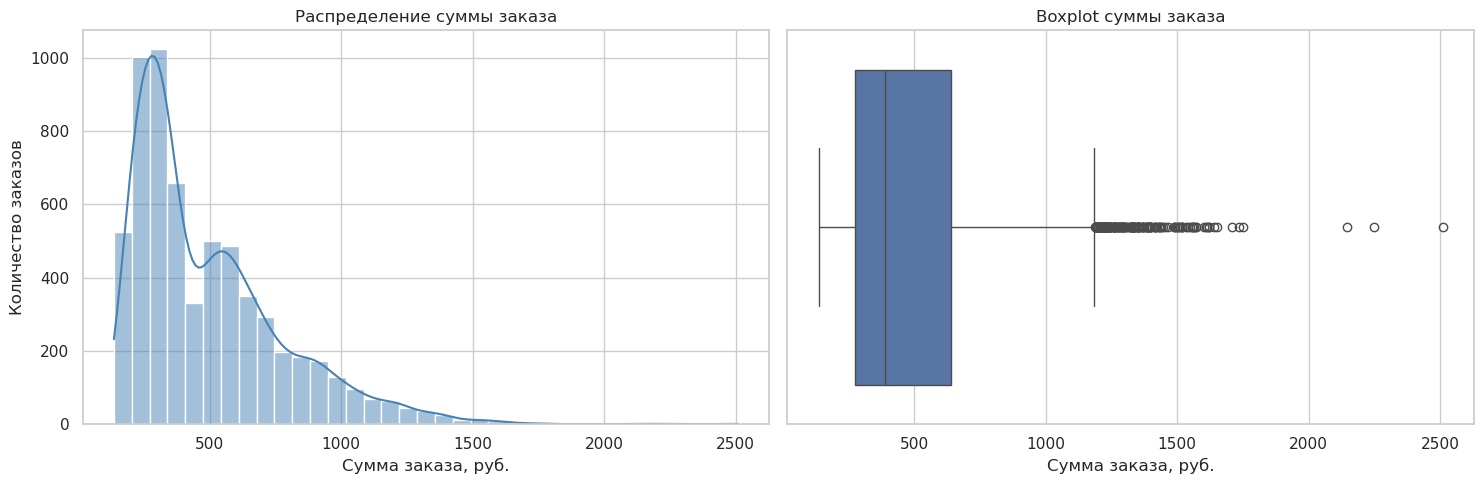

In [22]:
# Рассчитываем первый квартиль суммы заказа.
q1_order_revenue = orders_df['order_revenue_rub'].quantile(0.25)
# Рассчитываем третий квартиль суммы заказа.
q3_order_revenue = orders_df['order_revenue_rub'].quantile(0.75)
# Рассчитываем межквартильный размах.
iqr_order_revenue = q3_order_revenue - q1_order_revenue
# Рассчитываем верхнюю границу потенциального выброса.
upper_order_revenue_bound = q3_order_revenue + 1.5 * iqr_order_revenue
# Создаём флаг потенциального выброса по сумме заказа.
orders_df['order_revenue_outlier_iqr'] = orders_df['order_revenue_rub'] > upper_order_revenue_bound
# Печатаем границу и число потенциальных выбросов.
print(f'Верхняя IQR-граница: {upper_order_revenue_bound:,.2f} руб.; потенциальных выбросов: {orders_df["order_revenue_outlier_iqr"].sum()}.')
# Создаём фигуру с двумя графиками.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Строим гистограмму распределения суммы заказа.
sns.histplot(data=orders_df, x='order_revenue_rub', bins=35, kde=True, color='steelblue', ax=axes[0])
# Добавляем заголовок гистограммы.
axes[0].set_title('Распределение суммы заказа')
# Подписываем горизонтальную ось гистограммы.
axes[0].set_xlabel('Сумма заказа, руб.')
# Подписываем вертикальную ось гистограммы.
axes[0].set_ylabel('Количество заказов')
# Строим boxplot суммы заказа.
sns.boxplot(data=orders_df, x='order_revenue_rub', ax=axes[1])
# Добавляем заголовок boxplot.
axes[1].set_title('Boxplot суммы заказа')
# Подписываем горизонтальную ось boxplot.
axes[1].set_xlabel('Сумма заказа, руб.')
# Убираем подпись вертикальной оси boxplot.
axes[1].set_ylabel('')
# Автоматически корректируем расстояния между графиками.
plt.tight_layout()
# Показываем фигуру.
plt.show()

## 13. Временная динамика

Временной анализ выполняется на уровне заказов. Месячная агрегация показывает общий тренд, а тепловая карта «день недели × час» помогает увидеть внутринедельные и внутридневные пики.

Метод `pivot_table()` создаёт матрицу: строки — дни недели, столбцы — часы, значения — число заказов.

,month,revenue_rub,gross_profit_rub,orders,average_order_value_rub,revenue_growth_pct
0,2025-01-01,"197,938.25","120,026.25",407,486.33,NaN
1,2025-02-01,"211,218.25","127,752.25",441,478.95,6.71
2,2025-03-01,"248,530.50","151,002.50",508,489.23,17.67
3,2025-04-01,"255,115.00","153,067.00",506,504.18,2.65
4,2025-05-01,"246,965.75","150,157.75",500,493.93,-3.19
5,2025-06-01,"261,787.75","158,532.75",515,508.33,6.00
6,2025-07-01,"252,100.75","153,165.75",516,488.57,-3.70
7,2025-08-01,"231,268.75","140,142.75",461,501.67,-8.26
8,2025-09-01,"278,613.75","168,694.75",547,509.35,20.47
9,2025-10-01,"278,007.25","168,315.25",568,489.45,-0.22


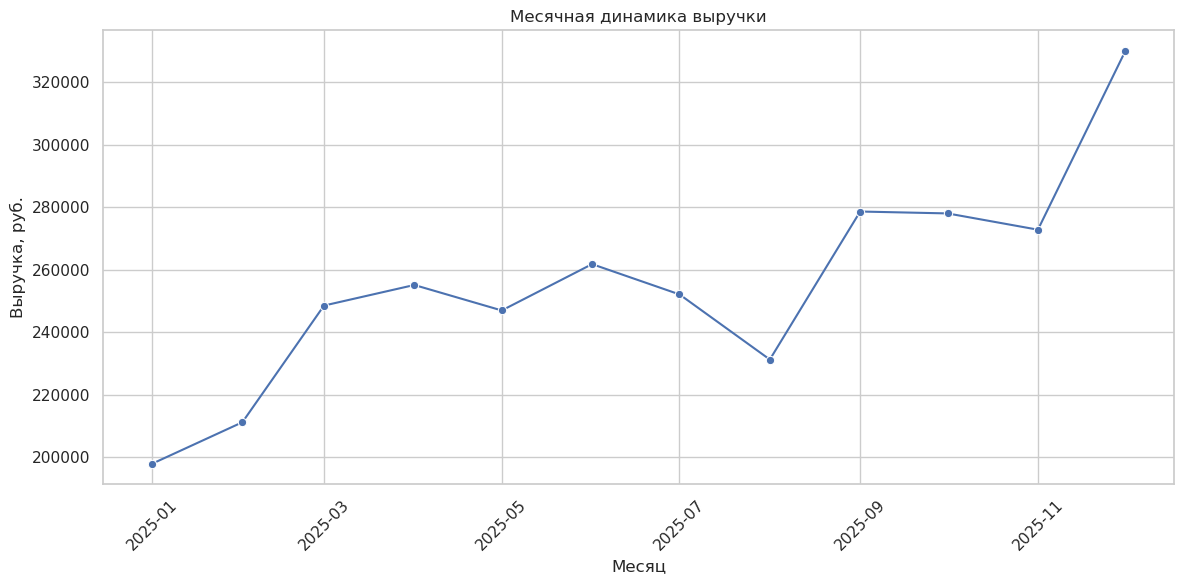

In [23]:
# Группируем заказы по месяцу и рассчитываем ключевые показатели.
monthly_summary = orders_df.groupby('month', as_index=False).agg(revenue_rub=('order_revenue_rub', 'sum'), gross_profit_rub=('order_gross_profit_rub', 'sum'), orders=('order_id', 'nunique'), average_order_value_rub=('order_revenue_rub', 'mean'))
# Рассчитываем темп изменения выручки к предыдущему месяцу.
monthly_summary['revenue_growth_pct'] = monthly_summary['revenue_rub'].pct_change() * 100
# Показываем месячную таблицу.
display(monthly_summary)
# Строим линейный график месячной выручки.
ax = sns.lineplot(data=monthly_summary, x='month', y='revenue_rub', marker='o')
# Добавляем заголовок графика.
ax.set_title('Месячная динамика выручки')
# Подписываем горизонтальную ось.
ax.set_xlabel('Месяц')
# Подписываем вертикальную ось.
ax.set_ylabel('Выручка, руб.')
# Поворачиваем подписи месяцев для читаемости.
plt.xticks(rotation=45)
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем график.
plt.show()

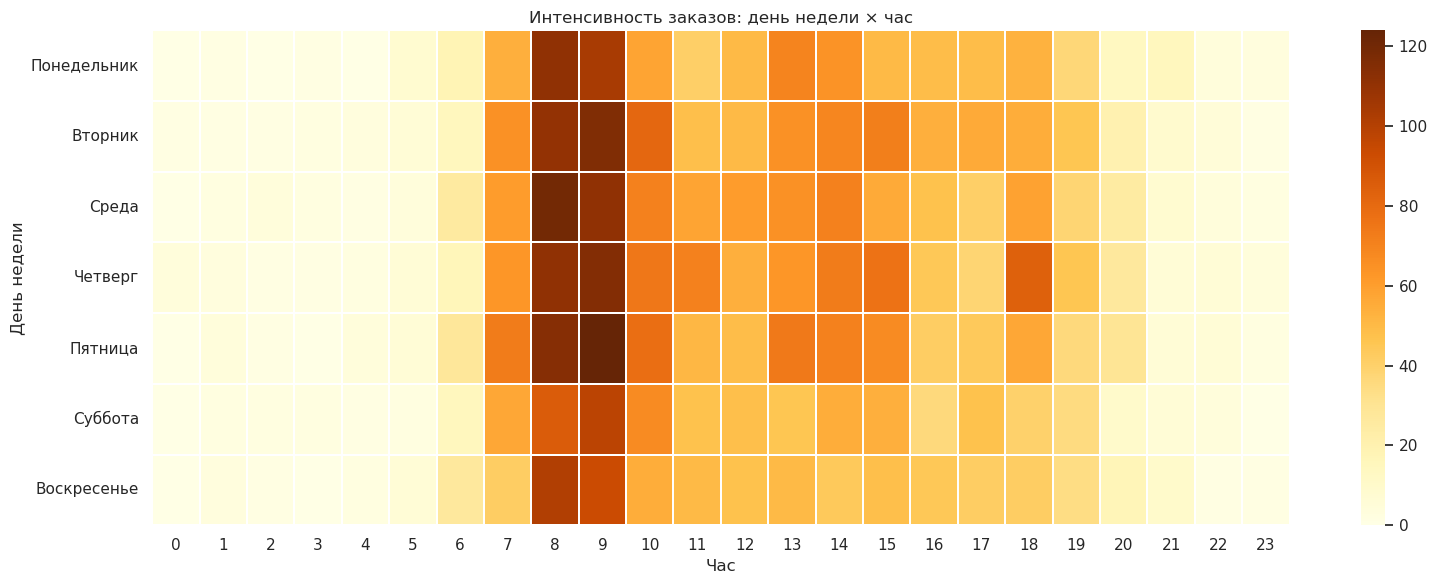

In [24]:
# Фиксируем логический порядок дней недели.
weekday_order = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
# Создаём сводную матрицу количества заказов по дню недели и часу.
weekday_hour_matrix = orders_df.pivot_table(index='weekday', columns='hour', values='order_id', aggfunc='nunique', fill_value=0)
# Переставляем строки матрицы в календарном порядке.
weekday_hour_matrix = weekday_hour_matrix.reindex(weekday_order)
# Создаём фигуру для тепловой карты.
plt.figure(figsize=(16, 6))
# Строим тепловую карту интенсивности заказов.
sns.heatmap(weekday_hour_matrix, cmap='YlOrBr', linewidths=0.2)
# Добавляем заголовок.
plt.title('Интенсивность заказов: день недели × час')
# Подписываем горизонтальную ось.
plt.xlabel('Час')
# Подписываем вертикальную ось.
plt.ylabel('День недели')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем тепловую карту.
plt.show()

## 14. Анализ товарных категорий и продуктов

Для категорий рассчитываются выручка, валовая прибыль, количество строк, количество проданных единиц и маржинальность. Для продуктов дополнительно строится рейтинг по выручке.

Маржинальность категории рассчитывается как сумма валовой прибыли, делённая на сумму выручки. Усреднение процентной маржи отдельных строк может дать другой и менее корректный результат.

,product_category,revenue_rub,gross_profit_rub,units,lines,margin_pct
2,Кофейные напитки,"1,928,187.00","1,239,571.00",6701,6098,64.29
0,Выпечка,"364,211.50","192,915.50",1759,1602,52.97
3,Сэндвичи,"270,742.00","125,109.00",700,638,46.21
4,Чай и другие напитки,"254,142.00","173,957.00",925,842,68.45
1,Десерты,"247,031.00","123,833.00",861,778,50.13


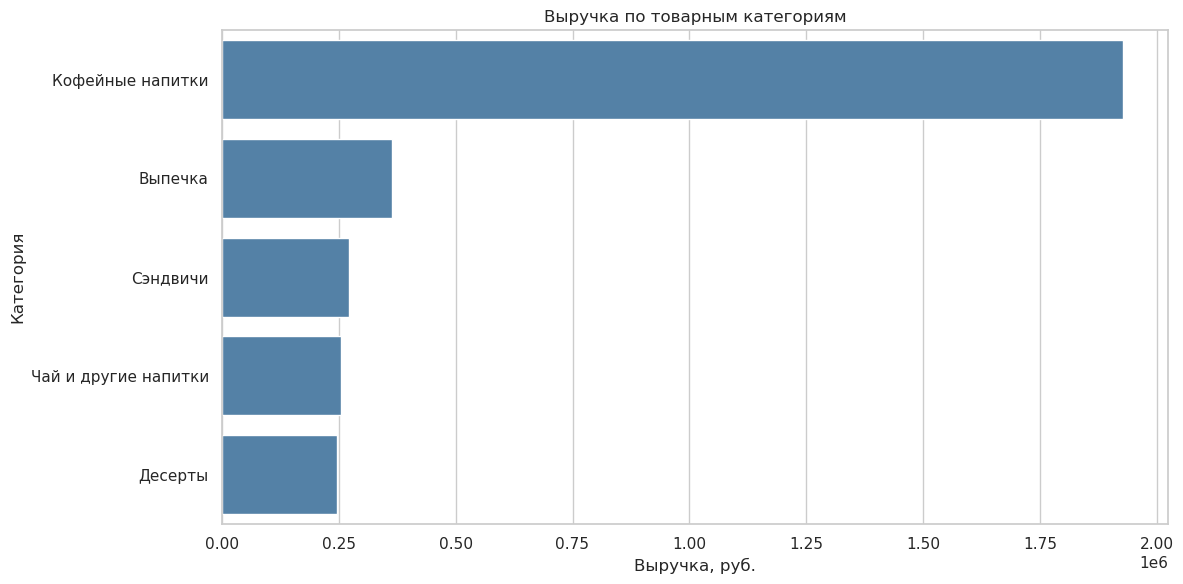

In [25]:
# Группируем строки по товарной категории.
category_summary = df.groupby('product_category', as_index=False).agg(revenue_rub=('net_revenue_rub', 'sum'), gross_profit_rub=('gross_profit_rub', 'sum'), units=('quantity', 'sum'), lines=('line_id', 'count'))
# Рассчитываем маржинальность категории как отношение суммарной прибыли к суммарной выручке.
category_summary['margin_pct'] = category_summary['gross_profit_rub'] / category_summary['revenue_rub'] * 100
# Сортируем категории по убыванию выручки.
category_summary = category_summary.sort_values('revenue_rub', ascending=False)
# Показываем категориальную сводку.
display(category_summary)
# Строим горизонтальную столбчатую диаграмму выручки по категориям.
ax = sns.barplot(data=category_summary, y='product_category', x='revenue_rub', color='steelblue')
# Добавляем заголовок.
ax.set_title('Выручка по товарным категориям')
# Подписываем горизонтальную ось.
ax.set_xlabel('Выручка, руб.')
# Подписываем вертикальную ось.
ax.set_ylabel('Категория')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем график.
plt.show()

,product_id,product_name,product_category,revenue_rub,gross_profit_rub,units,average_discount_pct,margin_pct
3,P004,Латте,Кофейные напитки,"462,998.75","292,535.75",1448,2.24,63.18
2,P003,Капучино,Кофейные напитки,"437,709.50","277,948.50",1506,2.28,63.50
5,P006,Раф,Кофейные напитки,"264,180.75","159,752.75",713,2.18,60.47
4,P005,Флэт уайт,Кофейные напитки,"233,822.25","147,400.25",714,2.16,63.04
1,P002,Американо,Кофейные напитки,"208,488.25","144,046.25",893,1.88,69.09
6,P007,Фильтр-кофе,Кофейные напитки,"180,102.75","122,174.75",692,2.26,67.84
0,P001,Эспрессо,Кофейные напитки,"140,884.75","95,712.75",735,2.22,67.94
17,P018,Сэндвич с индейкой,Сэндвичи,"126,515.50","58,660.50",331,1.92,46.37
11,P012,Круассан с сыром,Выпечка,"104,806.50","54,538.50",426,1.57,52.04
10,P011,Круассан классический,Выпечка,"103,035.00","55,219.00",556,2.35,53.59


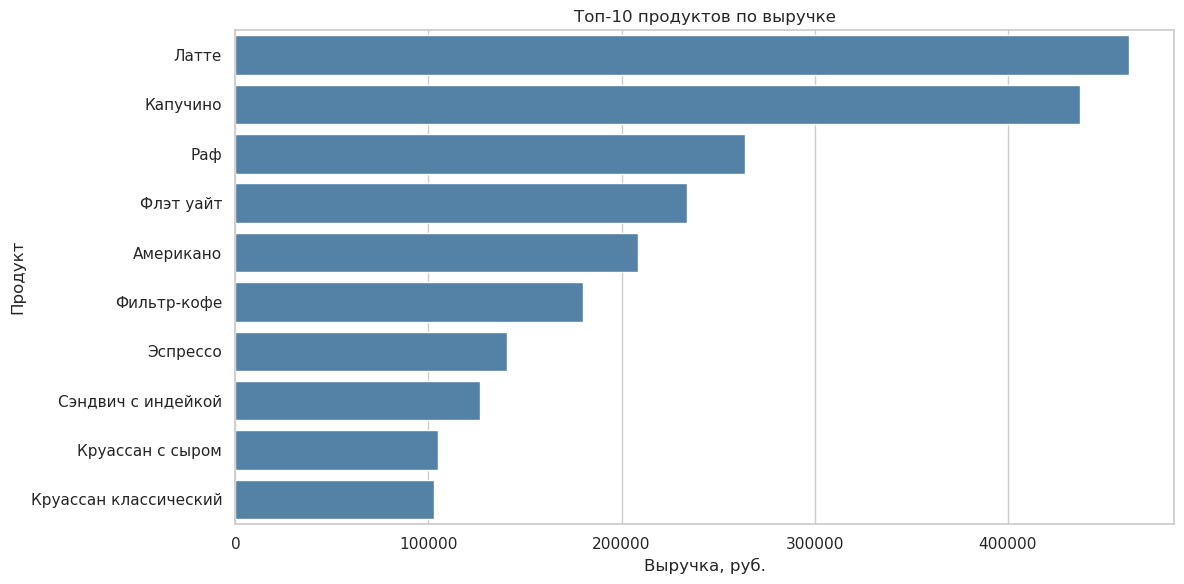

In [26]:
# Группируем строки по продукту и категории.
product_summary = df.groupby(['product_id', 'product_name', 'product_category'], as_index=False).agg(revenue_rub=('net_revenue_rub', 'sum'), gross_profit_rub=('gross_profit_rub', 'sum'), units=('quantity', 'sum'), average_discount_pct=('discount_pct', 'mean'))
# Рассчитываем маржинальность продукта.
product_summary['margin_pct'] = product_summary['gross_profit_rub'] / product_summary['revenue_rub'] * 100
# Сортируем продукты по выручке.
product_summary = product_summary.sort_values('revenue_rub', ascending=False)
# Выбираем десять продуктов с наибольшей выручкой.
top_products = product_summary.head(10)
# Показываем топ-10 продуктов.
display(top_products)
# Строим график топ-10 продуктов по выручке.
ax = sns.barplot(data=top_products, y='product_name', x='revenue_rub', color='steelblue')
# Добавляем заголовок.
ax.set_title('Топ-10 продуктов по выручке')
# Подписываем горизонтальную ось.
ax.set_xlabel('Выручка, руб.')
# Подписываем вертикальную ось.
ax.set_ylabel('Продукт')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем график.
plt.show()

## 15. Анализ каналов и программы лояльности

Каналы сравниваются по числу заказов, выручке, среднему чеку и марже. Программа лояльности рассматривается как сегмент, но результаты не интерпретируются причинно: участники программы могут систематически отличаться от гостей ещё до вступления.

,sales_channel,orders,revenue_rub,average_order_value_rub,gross_profit_rub,margin_pct,order_share_pct
1,Касса,3789,"1,566,042.50",413.31,"954,147.50",60.93,60.91
2,Мобильное приложение,1616,"811,597.00",502.23,"487,457.00",60.06,25.98
0,Доставка,816,"686,674.00",841.51,"413,781.00",60.26,13.12


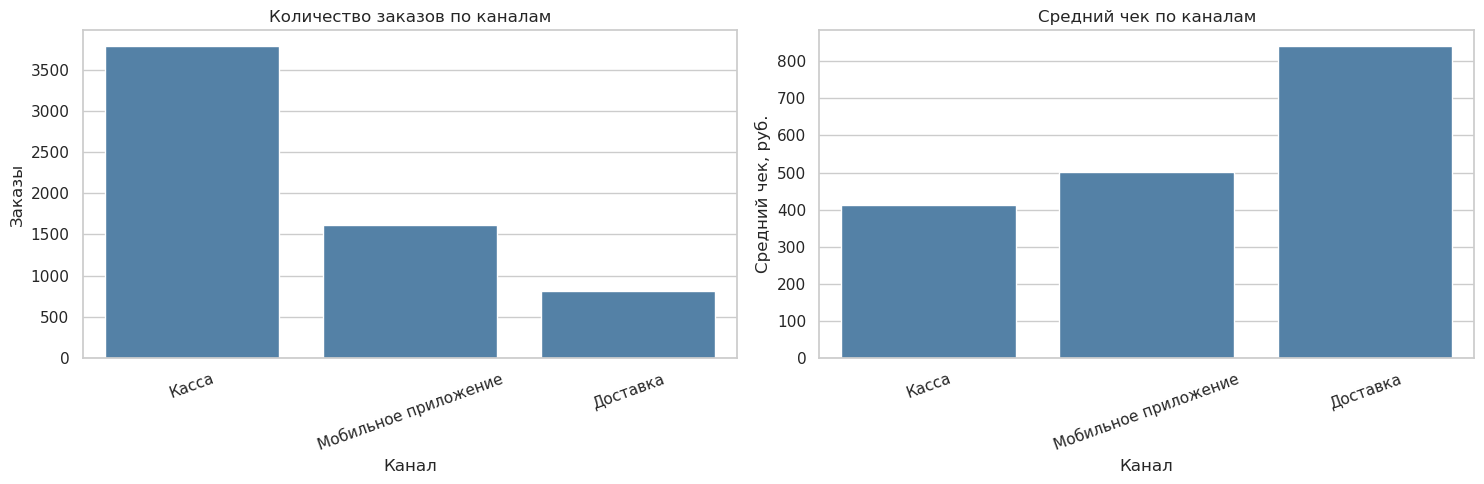

In [27]:
# Группируем заказы по каналу продаж.
channel_summary = orders_df.groupby('sales_channel', as_index=False).agg(orders=('order_id', 'nunique'), revenue_rub=('order_revenue_rub', 'sum'), average_order_value_rub=('order_revenue_rub', 'mean'), gross_profit_rub=('order_gross_profit_rub', 'sum'))
# Рассчитываем маржинальность канала.
channel_summary['margin_pct'] = channel_summary['gross_profit_rub'] / channel_summary['revenue_rub'] * 100
# Рассчитываем долю канала в числе заказов.
channel_summary['order_share_pct'] = channel_summary['orders'] / channel_summary['orders'].sum() * 100
# Сортируем каналы по выручке.
channel_summary = channel_summary.sort_values('revenue_rub', ascending=False)
# Показываем сводку по каналам.
display(channel_summary)
# Создаём фигуру с двумя графиками.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Строим график числа заказов по каналам.
sns.barplot(data=channel_summary, x='sales_channel', y='orders', color='steelblue', ax=axes[0])
# Добавляем заголовок первого графика.
axes[0].set_title('Количество заказов по каналам')
# Подписываем горизонтальную ось первого графика.
axes[0].set_xlabel('Канал')
# Подписываем вертикальную ось первого графика.
axes[0].set_ylabel('Заказы')
# Поворачиваем подписи категорий первого графика.
axes[0].tick_params(axis='x', rotation=20)
# Строим график среднего чека по каналам.
sns.barplot(data=channel_summary, x='sales_channel', y='average_order_value_rub', color='steelblue', ax=axes[1])
# Добавляем заголовок второго графика.
axes[1].set_title('Средний чек по каналам')
# Подписываем горизонтальную ось второго графика.
axes[1].set_xlabel('Канал')
# Подписываем вертикальную ось второго графика.
axes[1].set_ylabel('Средний чек, руб.')
# Поворачиваем подписи категорий второго графика.
axes[1].tick_params(axis='x', rotation=20)
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем фигуру.
plt.show()

In [28]:
# Группируем заказы по признаку участия в программе лояльности.
loyalty_summary = orders_df.groupby('loyalty_member', dropna=False, as_index=False).agg(orders=('order_id', 'nunique'), revenue_rub=('order_revenue_rub', 'sum'), average_order_value_rub=('order_revenue_rub', 'mean'), average_items=('items_quantity', 'mean'))
# Создаём читаемое название сегмента.
loyalty_summary['segment'] = loyalty_summary['loyalty_member'].map({True: 'Участники программы', False: 'Гости', pd.NA: 'Не определено'}).fillna('Не определено')
# Показываем сводку по лояльности.
display(loyalty_summary[['segment', 'orders', 'revenue_rub', 'average_order_value_rub', 'average_items']])

,segment,orders,revenue_rub,average_order_value_rub,average_items
0,Гости,2731,"1,327,666.25",486.15,1.73
1,Участники программы,3490,"1,736,647.25",497.61,1.78


## 16. Геоаналитика

Геоаналитика представлена в виде **векторной карты-схемы административных округов Москвы**, которая полностью формируется средствами Python.

В обновлённой версии:

- внешний контур Москвы строится по плотной системе опорных точек и имеет более естественную, нерегулярную форму;
- внутренние границы округов создаются как согласованные криволинейные границы, поэтому соседние полигоны не оставляют разрывов;
- каждый округ остаётся отдельным объектом `matplotlib.patches.Polygon`;
- аналитический пузырь рисуется объектом `matplotlib.patches.Circle`;
- центр пузыря автоматически ищется внутри соответствующего полигона;
- радиус пузыря ограничивается расстоянием до ближайшей границы округа, поэтому пузырь не выходит за пределы своего блока;
- размер пузыря отражает выручку административного округа;
- цвет пузыря отражает средний чек;
- подпись округа и пузырь размещаются раздельно, чтобы показатели не перекрывали название территории;
- готовые изображения, Base64, `imshow()` и внешние картографические подложки не используются.

Карта остаётся учебной схемой: она ближе к реальной радиально-секторной структуре Москвы, но не заменяет официальные геоданные и профессиональную ГИС.


,store_id,store_name,admin_district,district,latitude,longitude,orders,revenue_rub,gross_profit_rub,average_order_value_rub,margin_pct
1,S002,КофеТочка Тверская,ЦАО,Тверской,55.77,37.61,279,"139,523.50","84,416.50",500.08,60.50
4,S005,КофеТочка Пресня,ЦАО,Пресненский,55.76,37.56,276,"134,325.75","81,309.75",486.69,60.53
2,S003,КофеТочка Хамовники,ЦАО,Хамовники,55.73,37.57,275,"130,344.75","79,498.75",473.98,60.99
23,S024,КофеТочка Дорогомилово,ЗАО,Дорогомилово,55.74,37.57,252,"126,704.25","76,967.25",502.79,60.75
3,S004,КофеТочка Басманная,ЦАО,Басманный,55.77,37.67,241,"122,395.50","74,163.50",507.87,60.59
0,S001,КофеТочка Арбат,ЦАО,Арбат,55.75,37.59,237,"120,623.25","72,987.25",508.96,60.51
17,S018,КофеТочка Даниловская,ЮАО,Даниловский,55.71,37.62,228,"115,478.25","70,226.25",506.48,60.81
24,S025,КофеТочка Раменки,ЗАО,Раменки,55.70,37.51,215,"113,091.50","68,132.50",526.01,60.25
20,S021,КофеТочка Гагаринская,ЮЗАО,Гагаринский,55.70,37.55,233,"111,090.25","67,831.25",476.78,61.06
6,S007,КофеТочка Беговая,САО,Беговой,55.78,37.56,215,"108,103.75","65,357.75",502.81,60.46


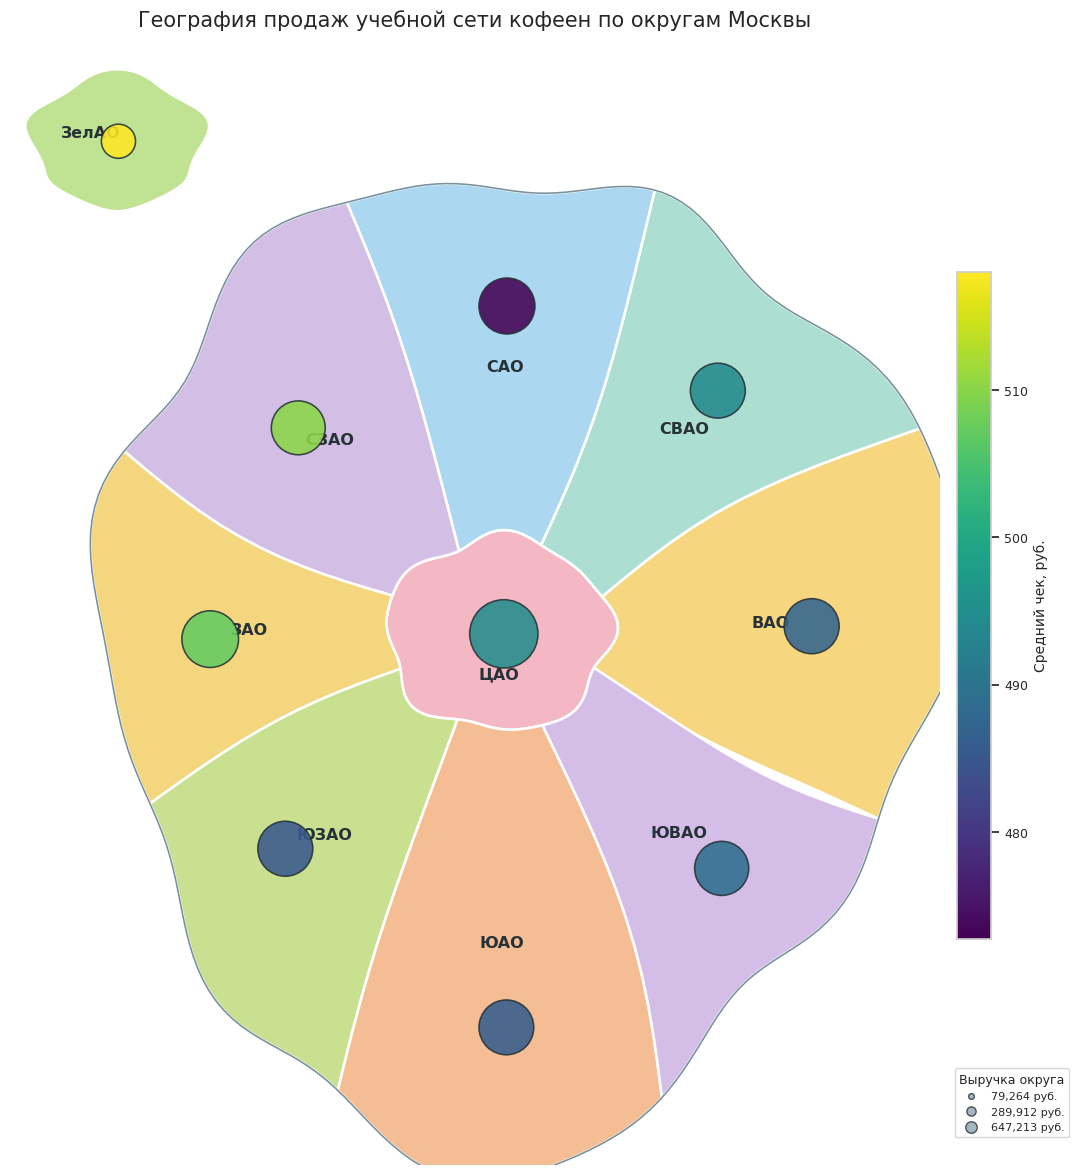

In [29]:
# Импортируем Polygon для программного построения округов как векторных многоугольников.
from matplotlib.patches import Polygon as MplPolygon
# Импортируем Circle для аналитических пузырей, которые должны оставаться внутри округов.
from matplotlib.patches import Circle
# Импортируем Path для проверки принадлежности точек внутренней области полигона.
from matplotlib.path import Path as MplPath
# Импортируем Normalize для преобразования среднего чека в цветовую шкалу.
from matplotlib.colors import Normalize
# Импортируем ScalarMappable для создания корректной цветовой шкалы.
from matplotlib.cm import ScalarMappable
# Импортируем Line2D для понятной легенды размеров пузырей.
from matplotlib.lines import Line2D

# Группируем заказы по торговой точке и географическим атрибутам.
store_summary = orders_df.groupby(
    ['store_id', 'store_name', 'admin_district', 'district', 'latitude', 'longitude'],
    as_index=False
).agg(
    orders=('order_id', 'nunique'),
    revenue_rub=('order_revenue_rub', 'sum'),
    gross_profit_rub=('order_gross_profit_rub', 'sum'),
    average_order_value_rub=('order_revenue_rub', 'mean')
)
# Рассчитываем маржинальность торговой точки.
store_summary['margin_pct'] = store_summary['gross_profit_rub'] / store_summary['revenue_rub'] * 100
# Сортируем точки по выручке.
store_summary = store_summary.sort_values('revenue_rub', ascending=False)
# Показываем десять лидирующих точек.
display(store_summary.head(10))

# Группируем данные по административным округам для отображения на карте.
map_district_summary = orders_df.groupby('admin_district', as_index=False).agg(
    revenue_rub=('order_revenue_rub', 'sum'),
    average_order_value_rub=('order_revenue_rub', 'mean'),
    orders=('order_id', 'nunique')
)

# Задаём общий центр основной части Москвы на условной координатной плоскости.
MOSCOW_CENTER_X = 5.20
# Задаём вертикальную координату центра основной части Москвы.
MOSCOW_CENTER_Y = 6.15

# Создаём функцию для циклической разницы углов в радианах.
def angular_distance(angle, target):
    # Переводим разницу углов в диапазон от -pi до +pi.
    return np.arctan2(np.sin(angle - target), np.cos(angle - target))

# Создаём функцию внешнего контура Москвы с детерминированной нерегулярностью.
def outer_boundary_point(angle):
    # Формируем мелкую волнистость, чтобы край не выглядел правильным эллипсом.
    edge_variation = (
        0.045 * np.sin(3 * angle + 0.35)
        + 0.028 * np.sin(7 * angle - 0.60)
        + 0.018 * np.cos(11 * angle + 0.20)
    )
    # Добавляем более выраженный восточный выступ.
    east_extension = 0.13 * np.exp(-(angular_distance(angle, 0.02) / 0.45) ** 2)
    # Добавляем южное вытяжение контура.
    south_extension = 0.09 * np.exp(-(angular_distance(angle, -np.pi / 2) / 0.55) ** 2)
    # Немного сужаем северо-западную часть.
    northwest_indent = -0.06 * np.exp(-(angular_distance(angle, 2.45) / 0.38) ** 2)
    # Объединяем локальные изменения внешней границы.
    scale = 1 + edge_variation + east_extension + south_extension + northwest_indent
    # Рассчитываем горизонтальную координату точки внешнего контура.
    x = MOSCOW_CENTER_X + 4.25 * scale * np.cos(angle)
    # Рассчитываем вертикальную координату точки внешнего контура.
    y = MOSCOW_CENTER_Y + 5.00 * scale * np.sin(angle)
    # Возвращаем координаты точки внешнего контура.
    return float(x), float(y)

# Создаём функцию внутреннего контура ЦАО.
def inner_boundary_point(angle):
    # Добавляем небольшую нерегулярность центральному контуру.
    inner_scale = 1 + 0.055 * np.sin(5 * angle + 0.70) + 0.025 * np.cos(8 * angle)
    # Рассчитываем горизонтальную координату внутренней границы.
    x = MOSCOW_CENTER_X + 1.18 * inner_scale * np.cos(angle)
    # Рассчитываем вертикальную координату внутренней границы.
    y = MOSCOW_CENTER_Y + 1.02 * inner_scale * np.sin(angle)
    # Возвращаем координаты точки внутренней границы.
    return float(x), float(y)

# Создаём согласованную криволинейную границу между двумя соседними округами.
def shared_radial_boundary(angle, point_count=14):
    # Получаем начальную точку на границе ЦАО.
    inner_x, inner_y = inner_boundary_point(angle)
    # Получаем конечную точку на внешнем контуре Москвы.
    outer_x, outer_y = outer_boundary_point(angle)
    # Создаём равномерные доли пути от внутренней к внешней границе.
    transition = np.linspace(0, 1, point_count)
    # Рассчитываем направление, перпендикулярное радиальной границе.
    perpendicular_x = -np.sin(angle)
    # Рассчитываем вторую компоненту перпендикулярного направления.
    perpendicular_y = np.cos(angle)
    # Задаём небольшую детерминированную амплитуду изгиба границы.
    bend_amplitude = 0.22 * np.sin(2.7 * angle + 0.55)
    # Задаём вторую волну, чтобы внутренняя граница не выглядела прямой радиальной линией.
    secondary_bend = 0.08 * np.cos(4.1 * angle - 0.30)
    # Создаём список точек общей границы.
    boundary_points = []
    # Перебираем точки перехода между внутренним и внешним контурами.
    for part in transition:
        # Рассчитываем плавный боковой изгиб, равный нулю на концах границы.
        bend = (
            bend_amplitude * np.sin(np.pi * part)
            + secondary_bend * np.sin(2 * np.pi * part)
        )
        # Интерполируем горизонтальную координату и добавляем изгиб.
        x = inner_x + (outer_x - inner_x) * part + perpendicular_x * bend
        # Интерполируем вертикальную координату и добавляем изгиб.
        y = inner_y + (outer_y - inner_y) * part + perpendicular_y * bend
        # Добавляем рассчитанную точку в границу.
        boundary_points.append((float(x), float(y)))
    # Возвращаем общую границу от ЦАО к внешнему контуру.
    return boundary_points

# Создаём внешний контур основной части Москвы из большого количества точек.
outer_ring_angles = np.linspace(-np.pi, np.pi, 241, endpoint=False)
# Преобразуем каждый угол во внешнюю координату.
moscow_outer_ring = [outer_boundary_point(angle) for angle in outer_ring_angles]

# Создаём внутренний контур ЦАО из большого количества точек.
inner_ring_angles = np.linspace(-np.pi, np.pi, 145, endpoint=False)
# Преобразуем каждый угол в координату внутренней границы.
moscow_inner_ring = [inner_boundary_point(angle) for angle in inner_ring_angles]

# Задаём угловые интервалы восьми округов вокруг ЦАО.
# Углы измеряются против часовой стрелки от восточного направления.
district_angle_ranges = {
    'ВАО': (-22.5, 22.5),
    'СВАО': (22.5, 67.5),
    'САО': (67.5, 112.5),
    'СЗАО': (112.5, 157.5),
    'ЗАО': (157.5, 202.5),
    'ЮЗАО': (202.5, 247.5),
    'ЮАО': (247.5, 292.5),
    'ЮВАО': (292.5, 337.5)
}

# Создаём функцию для построения одного секторного округа без разрывов с соседями.
def build_sector_polygon(start_degree, end_degree, arc_point_count=46):
    # Переводим начальный угол из градусов в радианы.
    start_angle = np.deg2rad(start_degree)
    # Переводим конечный угол из градусов в радианы.
    end_angle = np.deg2rad(end_degree)
    # Создаём последовательность углов внешней дуги округа.
    outer_angles = np.linspace(start_angle, end_angle, arc_point_count)
    # Рассчитываем точки внешней дуги.
    outer_arc = [outer_boundary_point(angle) for angle in outer_angles]
    # Получаем общую границу на конечном угле и разворачиваем её от внешнего края к ЦАО.
    end_boundary = list(reversed(shared_radial_boundary(end_angle)))
    # Создаём последовательность углов внутренней дуги в обратном направлении.
    inner_angles = np.linspace(end_angle, start_angle, max(18, arc_point_count // 2))
    # Рассчитываем точки внутренней дуги округа.
    inner_arc = [inner_boundary_point(angle) for angle in inner_angles]
    # Получаем общую границу на начальном угле от ЦАО к внешнему краю.
    start_boundary = shared_radial_boundary(start_angle)
    # Объединяем дуги и общие границы, исключая дублирующиеся конечные точки.
    polygon_points = (
        outer_arc
        + end_boundary[1:]
        + inner_arc[1:]
        + start_boundary[1:-1]
    )
    # Возвращаем координаты замкнутого секторного полигона.
    return polygon_points

# Создаём словарь полигонов административных округов.
moscow_district_polygons = {'ЦАО': moscow_inner_ring}
# Строим восемь окружающих округов по согласованным угловым секторам.
for district_name, angle_range in district_angle_ranges.items():
    # Создаём векторный полигон текущего округа.
    moscow_district_polygons[district_name] = build_sector_polygon(*angle_range)

# Создаём отдельный более естественный контур Зеленоградского округа.
zelenograd_angles = np.linspace(0, 2 * np.pi, 72, endpoint=False)
# Формируем нерегулярный замкнутый полигон Зеленограда.
moscow_district_polygons['ЗелАО'] = [
    (
        1.18 + 0.92 * (1 + 0.09 * np.sin(5 * angle)) * np.cos(angle),
        11.35 + 0.70 * (1 + 0.07 * np.cos(4 * angle)) * np.sin(angle)
    )
    for angle in zelenograd_angles
]

# Задаём пастельные цвета округов для читаемой учебной карты.
district_fill_colors = {
    'ЦАО': '#F4B6C2',
    'САО': '#A8D7F0',
    'СВАО': '#A9DED1',
    'ВАО': '#F6D57A',
    'ЮВАО': '#D3BCE7',
    'ЮАО': '#F4BB91',
    'ЮЗАО': '#C8DF8E',
    'ЗАО': '#F4D57B',
    'СЗАО': '#D2BCE6',
    'ЗелАО': '#BDE28F'
}

# Создаём функцию расчёта геометрического центра полигона по формуле площади.
def polygon_centroid(polygon_coordinates):
    # Преобразуем координаты в массив NumPy.
    coordinates = np.asarray(polygon_coordinates, dtype=float)
    # Выделяем горизонтальные координаты вершин.
    x = coordinates[:, 0]
    # Выделяем вертикальные координаты вершин.
    y = coordinates[:, 1]
    # Создаём сдвинутые массивы следующей вершины.
    next_x = np.roll(x, -1)
    # Создаём сдвинутый массив вертикальных координат следующей вершины.
    next_y = np.roll(y, -1)
    # Рассчитываем ориентированные поперечные произведения соседних вершин.
    cross = x * next_y - next_x * y
    # Рассчитываем удвоенную ориентированную площадь полигона.
    signed_area_twice = cross.sum()
    # Если площадь близка к нулю, используем среднее значение координат.
    if np.isclose(signed_area_twice, 0):
        # Возвращаем среднее положение вершин.
        return float(x.mean()), float(y.mean())
    # Рассчитываем горизонтальную координату геометрического центра.
    centroid_x = ((x + next_x) * cross).sum() / (3 * signed_area_twice)
    # Рассчитываем вертикальную координату геометрического центра.
    centroid_y = ((y + next_y) * cross).sum() / (3 * signed_area_twice)
    # Возвращаем геометрический центр полигона.
    return float(centroid_x), float(centroid_y)

# Создаём функцию минимального расстояния от набора точек до границы полигона.
def minimum_distance_to_polygon_edges(points, polygon_coordinates):
    # Преобразуем проверяемые точки в массив NumPy.
    point_array = np.asarray(points, dtype=float)
    # Преобразуем вершины полигона в массив NumPy.
    polygon_array = np.asarray(polygon_coordinates, dtype=float)
    # Создаём начальные точки всех рёбер полигона.
    edge_start = polygon_array
    # Создаём конечные точки всех рёбер полигона.
    edge_end = np.roll(polygon_array, -1, axis=0)
    # Формируем векторы рёбер.
    edge_vector = edge_end - edge_start
    # Рассчитываем квадрат длины каждого ребра и защищаемся от нулевой длины.
    edge_length_squared = np.maximum((edge_vector ** 2).sum(axis=1), 1e-12)
    # Создаём массив для минимального расстояния каждой точки.
    minimum_distance = np.full(len(point_array), np.inf)
    # Последовательно проверяем расстояние до каждого ребра.
    for start, vector, length_squared in zip(edge_start, edge_vector, edge_length_squared):
        # Формируем векторы от начала ребра до всех проверяемых точек.
        point_vector = point_array - start
        # Рассчитываем положение ортогональной проекции на отрезок.
        projection = np.clip((point_vector @ vector) / length_squared, 0, 1)
        # Рассчитываем координаты ближайшей точки на текущем отрезке.
        nearest_point = start + projection[:, None] * vector
        # Рассчитываем расстояние от проверяемой точки до текущего ребра.
        distance = np.sqrt(((point_array - nearest_point) ** 2).sum(axis=1))
        # Обновляем минимальное расстояние до границы.
        minimum_distance = np.minimum(minimum_distance, distance)
    # Возвращаем минимальное расстояние каждой точки до границы полигона.
    return minimum_distance

# Создаём функцию поиска безопасного центра пузыря внутри полигона.
def find_safe_bubble_position(polygon_coordinates, outward_direction=None, grid_size=76):
    # Преобразуем координаты полигона в массив NumPy.
    polygon_array = np.asarray(polygon_coordinates, dtype=float)
    # Создаём объект Path для проверки попадания точек внутрь полигона.
    polygon_path = MplPath(polygon_array, closed=True)
    # Определяем горизонтальный диапазон полигона.
    minimum_x, maximum_x = polygon_array[:, 0].min(), polygon_array[:, 0].max()
    # Определяем вертикальный диапазон полигона.
    minimum_y, maximum_y = polygon_array[:, 1].min(), polygon_array[:, 1].max()
    # Создаём регулярную сетку кандидатов внутри ограничивающего прямоугольника.
    grid_x, grid_y = np.meshgrid(
        np.linspace(minimum_x, maximum_x, grid_size),
        np.linspace(minimum_y, maximum_y, grid_size)
    )
    # Объединяем координаты сетки в список двумерных точек.
    candidates = np.column_stack([grid_x.ravel(), grid_y.ravel()])
    # Проверяем, какие кандидаты находятся строго внутри полигона.
    inside_mask = polygon_path.contains_points(candidates, radius=-1e-9)
    # Оставляем только внутренние точки.
    inside_candidates = candidates[inside_mask]
    # Если внутренние точки не найдены, используем геометрический центр.
    if len(inside_candidates) == 0:
        # Возвращаем центр и нулевое расстояние до границы.
        centroid_x, centroid_y = polygon_centroid(polygon_coordinates)
        return centroid_x, centroid_y, 0.0
    # Рассчитываем запас до ближайшей границы для каждого кандидата.
    clearance = minimum_distance_to_polygon_edges(inside_candidates, polygon_coordinates)
    # Рассчитываем геометрический центр полигона.
    centroid = np.asarray(polygon_centroid(polygon_coordinates))
    # Если направление не задано, используем сам геометрический центр как целевую точку.
    if outward_direction is None:
        # Задаём целевую точку в геометрическом центре.
        target = centroid
    else:
        # Нормализуем направление смещения пузыря.
        direction = np.asarray(outward_direction, dtype=float)
        # Защищаемся от нулевой длины вектора.
        direction = direction / max(np.linalg.norm(direction), 1e-12)
        # Немного сдвигаем целевую точку от крупной подписи округа к внешней части сектора.
        target = centroid + direction * 0.78
    # Рассчитываем расстояние кандидатов до целевой точки.
    target_distance = np.sqrt(((inside_candidates - target) ** 2).sum(axis=1))
    # Выбираем точку с большим запасом до границы и умеренной близостью к целевой позиции.
    score = clearance - 0.19 * target_distance
    # Находим индекс лучшей безопасной позиции.
    best_index = int(np.argmax(score))
    # Возвращаем координаты и фактический запас до границы.
    return (
        float(inside_candidates[best_index, 0]),
        float(inside_candidates[best_index, 1]),
        float(clearance[best_index])
    )

# Создаём словарь позиций крупных подписей округов отдельно от аналитических пузырей.
district_label_positions = {}
# Перебираем полигоны округов.
for district_name, polygon_coordinates in moscow_district_polygons.items():
    # Рассчитываем геометрический центр текущего округа.
    centroid_x, centroid_y = polygon_centroid(polygon_coordinates)
    # Для ЦАО сдвигаем подпись вниз, оставляя верхнюю часть под аналитический пузырь.
    if district_name == 'ЦАО':
        # Сохраняем отдельную позицию подписи центрального округа.
        district_label_positions[district_name] = (centroid_x, centroid_y - 0.42)
    # Для Зеленограда сдвигаем подпись влево от пузыря.
    elif district_name == 'ЗелАО':
        # Сохраняем отдельную позицию подписи Зеленограда.
        district_label_positions[district_name] = (centroid_x - 0.28, centroid_y + 0.08)
    else:
        # Формируем направление от центра Москвы к геометрическому центру округа.
        direction = np.asarray((centroid_x - MOSCOW_CENTER_X, centroid_y - MOSCOW_CENTER_Y), dtype=float)
        # Нормализуем направление.
        direction = direction / max(np.linalg.norm(direction), 1e-12)
        # Сдвигаем подпись к внутренней части сектора, освобождая место для пузыря снаружи.
        district_label_positions[district_name] = (
            centroid_x - direction[0] * 0.36,
            centroid_y - direction[1] * 0.36
        )

# Создаём безопасные позиции пузырей и сохраняем расстояние до границы каждого округа.
district_bubble_layout = {}
# Перебираем все полигоны округов.
for district_name, polygon_coordinates in moscow_district_polygons.items():
    # Для основной части Москвы рассчитываем направление от центра города к округу.
    if district_name == 'ЦАО':
        # Для центрального округа направляем пузырь вверх относительно подписи.
        outward_direction = (0.0, 1.0)
    elif district_name != 'ЗелАО':
        # Получаем геометрический центр полигона текущего округа.
        centroid_x, centroid_y = polygon_centroid(polygon_coordinates)
        # Формируем направление к внешней части округа.
        outward_direction = (centroid_x - MOSCOW_CENTER_X, centroid_y - MOSCOW_CENTER_Y)
    else:
        # Для Зеленограда используем смещение вправо и немного вниз.
        outward_direction = (0.85, -0.20)
    # Находим безопасный центр пузыря и запас до границы.
    bubble_x, bubble_y, boundary_clearance = find_safe_bubble_position(
        polygon_coordinates,
        outward_direction=outward_direction
    )
    # Сохраняем рассчитанную геометрию пузыря.
    district_bubble_layout[district_name] = {
        'map_x': bubble_x,
        'map_y': bubble_y,
        'boundary_clearance': boundary_clearance
    }

# Создаём функцию для одной и той же карты в разделе геоаналитики и дашборде.
def draw_moscow_sales_map(
    ax,
    district_data,
    title,
    compact=False,
    show_colorbar=True,
    show_size_legend=True
):
    # Копируем агрегированные данные, чтобы не изменять исходную таблицу.
    plot_data = district_data.copy()
    # Добавляем безопасную горизонтальную координату пузыря.
    plot_data['map_x'] = plot_data['admin_district'].map(
        lambda district: district_bubble_layout.get(district, {}).get('map_x', np.nan)
    )
    # Добавляем безопасную вертикальную координату пузыря.
    plot_data['map_y'] = plot_data['admin_district'].map(
        lambda district: district_bubble_layout.get(district, {}).get('map_y', np.nan)
    )
    # Добавляем расстояние от центра пузыря до ближайшей границы полигона.
    plot_data['boundary_clearance'] = plot_data['admin_district'].map(
        lambda district: district_bubble_layout.get(district, {}).get('boundary_clearance', np.nan)
    )
    # Удаляем округа без рассчитанной позиции.
    plot_data = plot_data.dropna(subset=['map_x', 'map_y', 'boundary_clearance'])

    # Рассчитываем минимальную выручку для масштабирования пузырей.
    minimum_revenue = plot_data['revenue_rub'].min()
    # Рассчитываем максимальную выручку для масштабирования пузырей.
    maximum_revenue = plot_data['revenue_rub'].max()
    # Защищаем формулу нормализации от деления на ноль.
    revenue_range = max(maximum_revenue - minimum_revenue, 1)
    # Нормализуем выручку каждого округа в диапазон от 0 до 1.
    plot_data['revenue_normalized'] = (
        plot_data['revenue_rub'] - minimum_revenue
    ) / revenue_range
    # Рассчитываем желаемый радиус пузыря в координатах карты.
    plot_data['desired_radius'] = 0.18 + 0.18 * np.sqrt(plot_data['revenue_normalized'])
    # Ограничиваем радиус 62% запаса до границы, чтобы круг гарантированно оставался внутри округа.
    plot_data['bubble_radius'] = np.minimum(
        plot_data['desired_radius'],
        plot_data['boundary_clearance'] * 0.62
    )
    # Защищаем радиус от слишком малого значения в случае численной погрешности.
    plot_data['bubble_radius'] = plot_data['bubble_radius'].clip(lower=0.06)

    # Рисуем каждый округ как самостоятельный векторный многоугольник.
    for district_name, polygon_coordinates in moscow_district_polygons.items():
        # Создаём объект Polygon по рассчитанным числовым координатам.
        district_patch = MplPolygon(
            polygon_coordinates,
            closed=True,
            facecolor=district_fill_colors[district_name],
            edgecolor='white',
            linewidth=1.25 if compact else 1.9,
            alpha=0.97,
            joinstyle='round',
            zorder=1
        )
        # Добавляем полигон округа на текущую ось.
        ax.add_patch(district_patch)

    # Добавляем тонкий внешний контур основной части Москвы.
    city_outline = MplPolygon(
        moscow_outer_ring,
        closed=True,
        fill=False,
        edgecolor='#607D8B',
        linewidth=0.75 if compact else 1.15,
        alpha=0.85,
        zorder=2
    )
    # Добавляем внешний контур поверх цветных округов.
    ax.add_patch(city_outline)

    # Добавляем крупные подписи округов внутри соответствующих полигонов.
    for district_name, label_coordinates in district_label_positions.items():
        # Выбираем размер шрифта для компактной или полной карты.
        label_font_size = 6.7 if compact else 11.5
        # Добавляем название округа.
        ax.text(
            label_coordinates[0],
            label_coordinates[1],
            district_name,
            ha='center',
            va='center',
            fontsize=label_font_size,
            fontweight='bold',
            color='#263238',
            zorder=3
        )

    # Настраиваем нормализацию цвета среднего чека.
    color_norm = Normalize(
        vmin=plot_data['average_order_value_rub'].min(),
        vmax=plot_data['average_order_value_rub'].max()
    )
    # Получаем цветовую палитру viridis.
    color_map = plt.get_cmap('viridis')

    # Рисуем аналитические пузыри как круги в координатах карты.
    for _, row in plot_data.iterrows():
        # Определяем цвет пузыря по среднему чеку округа.
        bubble_color = color_map(color_norm(row['average_order_value_rub']))
        # Создаём круг с рассчитанным безопасным радиусом.
        bubble = Circle(
            (row['map_x'], row['map_y']),
            radius=row['bubble_radius'],
            facecolor=bubble_color,
            edgecolor='#263238',
            linewidth=0.8 if compact else 1.15,
            alpha=0.88,
            zorder=4
        )
        # Добавляем круг на карту.
        ax.add_patch(bubble)
        # Не дублируем название внутри пузыря: округ уже подписан на самом полигоне.

    # Фиксируем горизонтальные границы карты.
    ax.set_xlim(0.05, 9.85)
    # Фиксируем вертикальные границы карты.
    ax.set_ylim(0.55, 12.35)
    # Сохраняем одинаковый масштаб по обеим осям.
    ax.set_aspect('equal')
    # Убираем координатные оси и сетку.
    ax.axis('off')
    # Добавляем заголовок карты.
    ax.set_title(title, fontsize=10 if compact else 15, pad=8 if compact else 14)

    # При необходимости добавляем цветовую шкалу среднего чека.
    if show_colorbar:
        # Создаём объект для цветовой шкалы с той же нормализацией.
        color_mappable = ScalarMappable(norm=color_norm, cmap=color_map)
        # Передаём значения для построения шкалы.
        color_mappable.set_array(plot_data['average_order_value_rub'])
        # Добавляем цветовую шкалу рядом с картой.
        colorbar = ax.figure.colorbar(
            color_mappable,
            ax=ax,
            fraction=0.034 if not compact else 0.045,
            pad=0.018
        )
        # Подписываем смысл цветовой шкалы.
        colorbar.set_label('Средний чек, руб.', fontsize=8 if compact else 10)
        # Настраиваем размер подписей шкалы.
        colorbar.ax.tick_params(labelsize=7 if compact else 9)

    # При необходимости добавляем легенду размера пузырей.
    if show_size_legend:
        # Выбираем минимальную, медианную и максимальную выручку как ориентиры.
        revenue_legend_values = [
            minimum_revenue,
            plot_data['revenue_rub'].median(),
            maximum_revenue
        ]
        # Создаём список элементов легенды.
        revenue_legend_handles = []
        # Перебираем ориентиры выручки.
        for revenue_value in revenue_legend_values:
            # Нормализуем ориентир по той же формуле.
            normalized_value = (revenue_value - minimum_revenue) / revenue_range
            # Рассчитываем условный радиус легенды.
            legend_radius = 0.18 + 0.18 * np.sqrt(max(normalized_value, 0))
            # Создаём круговой маркер для легенды.
            legend_handle = Line2D(
                [0],
                [0],
                marker='o',
                linestyle='none',
                markerfacecolor='#90A4AE',
                markeredgecolor='#263238',
                markersize=legend_radius * 23,
                alpha=0.80,
                label=f'{revenue_value:,.0f} руб.'
            )
            # Добавляем маркер в список легенды.
            revenue_legend_handles.append(legend_handle)
        # Выводим легенду справа от карты.
        ax.legend(
            handles=revenue_legend_handles,
            title='Выручка округа',
            loc='lower left',
            bbox_to_anchor=(1.01, 0.02),
            frameon=True,
            fontsize=8,
            title_fontsize=9
        )

    # Возвращаем подготовленные данные для последующих QA-проверок.
    return plot_data

# Создаём отдельную фигуру для подробной географической визуализации.
fig, geo_ax = plt.subplots(figsize=(11, 12))
# Строим реалистичную учебную карту только из Python-геометрии.
map_plot_data = draw_moscow_sales_map(
    ax=geo_ax,
    district_data=map_district_summary,
    title='География продаж учебной сети кофеен по округам Москвы',
    compact=False,
    show_colorbar=True,
    show_size_legend=True
)
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем готовую карту.
plt.show()


,admin_district,orders,revenue_rub,average_order_value_rub,gross_profit_rub,margin_pct
6,ЦАО,1308,"647,212.75",494.81,"392,375.75",60.63
1,ЗАО,645,"327,091.25",507.12,"197,770.25",60.46
3,САО,659,"311,527.75",472.73,"188,828.75",60.61
0,ВАО,598,"291,514.75",487.48,"176,714.75",60.62
9,ЮЗАО,599,"290,691.00",485.29,"176,839.00",60.83
4,СВАО,585,"289,133.50",494.25,"175,009.50",60.53
7,ЮАО,589,"286,271.25",486.03,"173,735.25",60.69
8,ЮВАО,558,"272,776.00",488.85,"164,605.00",60.34
5,СЗАО,527,"268,831.50",510.12,"161,592.50",60.11
2,ЗелАО,153,"79,263.75",518.06,"47,914.75",60.45


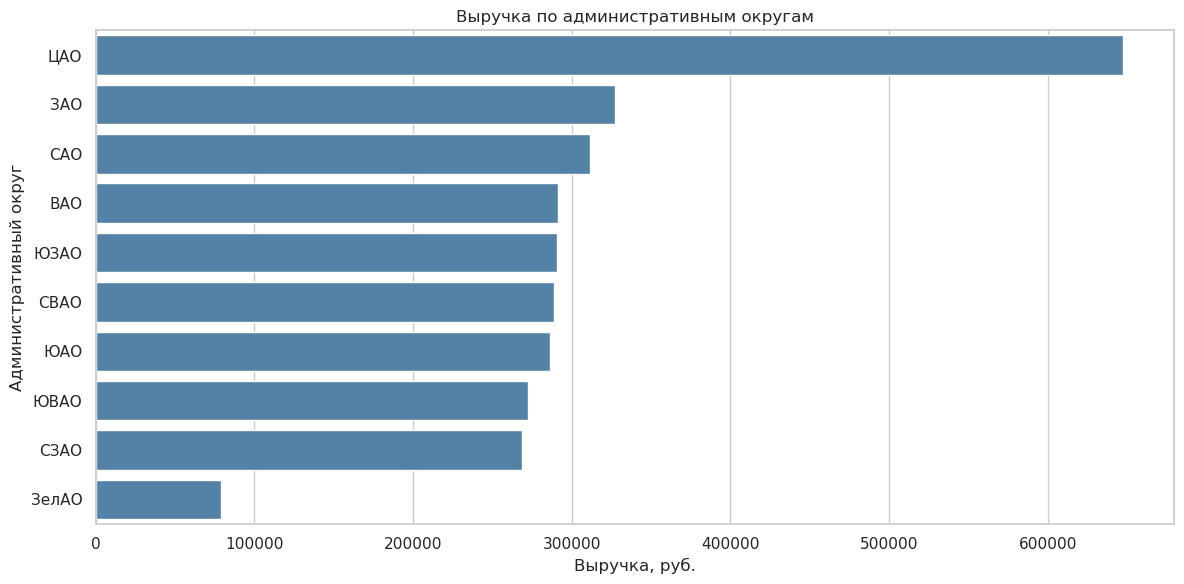

In [30]:
# Группируем заказы по административному округу.
district_summary = orders_df.groupby('admin_district', as_index=False).agg(orders=('order_id', 'nunique'), revenue_rub=('order_revenue_rub', 'sum'), average_order_value_rub=('order_revenue_rub', 'mean'), gross_profit_rub=('order_gross_profit_rub', 'sum'))
# Рассчитываем маржинальность округа.
district_summary['margin_pct'] = district_summary['gross_profit_rub'] / district_summary['revenue_rub'] * 100
# Сортируем округа по выручке.
district_summary = district_summary.sort_values('revenue_rub', ascending=False)
# Показываем географическую сводку по округам.
display(district_summary)
# Строим горизонтальную диаграмму выручки по округам.
ax = sns.barplot(data=district_summary, y='admin_district', x='revenue_rub', color='steelblue')
# Добавляем заголовок.
ax.set_title('Выручка по административным округам')
# Подписываем горизонтальную ось.
ax.set_xlabel('Выручка, руб.')
# Подписываем вертикальную ось.
ax.set_ylabel('Административный округ')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем график.
plt.show()

## 17. Корреляционная матрица и тепловая карта

Корреляция Пирсона измеряет направление и силу **линейной** связи двух числовых признаков от −1 до +1.

- значение около +1 означает сильную положительную линейную связь;
- значение около −1 означает сильную отрицательную линейную связь;
- значение около 0 означает отсутствие выраженной линейной связи.

### Ограничения

- корреляция не доказывает причинность;
- результат чувствителен к выбросам;
- математически связанные показатели, например выручка и прибыль, ожидаемо коррелируют;
- категориальные признаки нельзя автоматически интерпретировать через обычную корреляцию Пирсона.

Тепловая карта является визуальным представлением матрицы корреляций: цвет кодирует знак и величину коэффициента.

,order_revenue_rub,order_gross_profit_rub,items_quantity,line_count,unique_products,discount_pct,hour,order_margin_pct
order_revenue_rub,1.00,0.98,0.94,0.84,0.79,-0.05,0.07,-0.06
order_gross_profit_rub,0.98,1.00,0.93,0.83,0.78,-0.10,0.06,0.11
items_quantity,0.94,0.93,1.00,0.90,0.85,0.04,0.05,-0.02
line_count,0.84,0.83,0.90,1.00,0.95,0.03,0.06,-0.03
unique_products,0.79,0.78,0.85,0.95,1.00,0.03,0.07,-0.04
discount_pct,-0.05,-0.10,0.04,0.03,0.03,1.00,-0.01,-0.31
hour,0.07,0.06,0.05,0.06,0.07,-0.01,1.00,-0.06
order_margin_pct,-0.06,0.11,-0.02,-0.03,-0.04,-0.31,-0.06,1.00


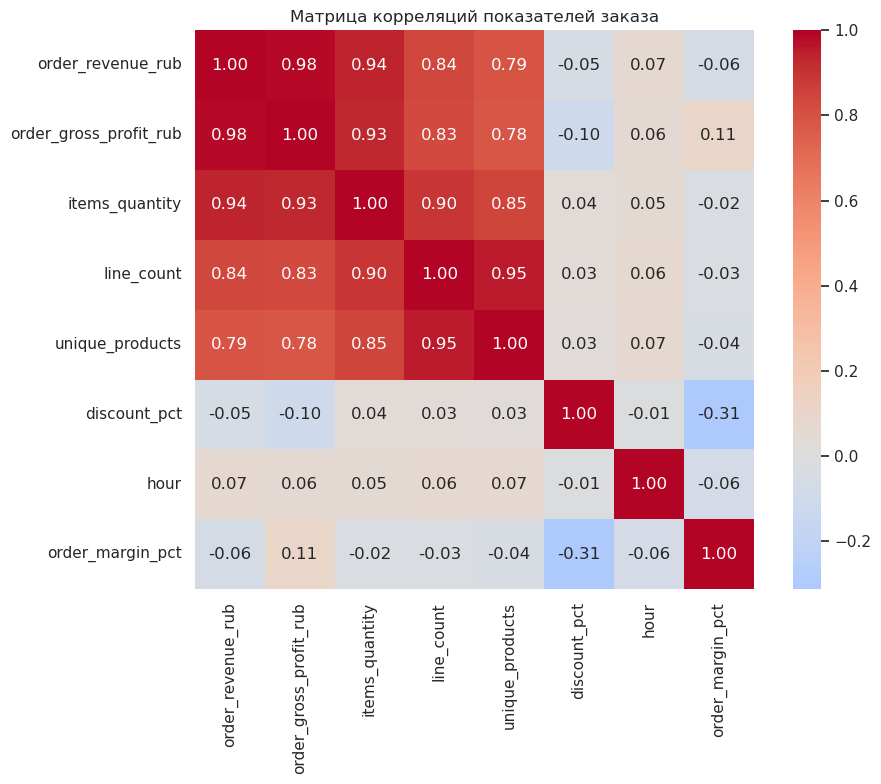

In [31]:
# Выбираем числовые показатели на уровне заказа для корреляционного анализа.
correlation_columns = ['order_revenue_rub', 'order_gross_profit_rub', 'items_quantity', 'line_count', 'unique_products', 'discount_pct', 'hour', 'order_margin_pct']
# Рассчитываем матрицу корреляций Пирсона.
correlation_matrix = orders_df[correlation_columns].corr(method='pearson')
# Показываем числовую матрицу корреляций.
display(correlation_matrix)
# Создаём фигуру для тепловой карты.
plt.figure(figsize=(10, 8))
# Строим тепловую карту с подписями коэффициентов.
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
# Добавляем заголовок.
plt.title('Матрица корреляций показателей заказа')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем тепловую карту.
plt.show()

## 18. Статистическая проверка гипотезы

### Почему выбран тест Манна—Уитни

Сумма заказа обычно имеет правостороннюю асимметрию и выбросы. Тест Манна—Уитни — непараметрический метод сравнения двух независимых выборок. Он не требует нормального распределения значений, но предполагает независимость наблюдений и сопоставимость формы распределений при интерпретации как сдвига положения.

### Что рассчитывается

- `U` — статистика теста;
- `p-value` — вероятность получить не менее выраженное различие при условии истинности H0;
- рангово-бисериальная корреляция — размер эффекта от −1 до +1;
- bootstrap-интервал разницы медиан — оценка неопределённости практической разницы.

`p-value < 0.05` означает основание отвергнуть H0 в рамках выбранного теста, но не доказывает причинное влияние канала.

> **Ограничение независимости:** в учебном наборе один участник программы лояльности может совершить несколько заказов. В расчёте заказы рассматриваются как отдельные операционные наблюдения, поэтому строгая независимость может нарушаться. p-value следует интерпретировать как учебную оценку; в реальной задаче требуется кластерный bootstrap по клиенту, модель со случайными эффектами или иной метод, учитывающий повторные покупки.

In [32]:
# Выбираем суммы заказов, оформленных через кассу.
cash_orders = orders_df.loc[orders_df['sales_channel'] == 'Касса', 'order_revenue_rub'].dropna()
# Выбираем суммы заказов, оформленных через мобильное приложение.
app_orders = orders_df.loc[orders_df['sales_channel'] == 'Мобильное приложение', 'order_revenue_rub'].dropna()
# Выполняем двусторонний тест Манна—Уитни для независимых выборок.
mann_whitney_result = mannwhitneyu(cash_orders, app_orders, alternative='two-sided')
# Извлекаем статистику U для первой выборки.
u_statistic = float(mann_whitney_result.statistic)
# Извлекаем p-value.
p_value = float(mann_whitney_result.pvalue)
# Рассчитываем рангово-бисериальную корреляцию как размер эффекта.
rank_biserial = 2 * u_statistic / (len(cash_orders) * len(app_orders)) - 1
# Рассчитываем наблюдаемую разницу медиан приложения и кассы.
median_difference = float(app_orders.median() - cash_orders.median())
# Задаём число bootstrap-повторов.
bootstrap_iterations = 3000
# Создаём пустой массив для bootstrap-разниц медиан.
bootstrap_differences = np.empty(bootstrap_iterations)
# Запускаем цикл bootstrap-повторов.
for iteration in range(bootstrap_iterations):
    # Случайно выбираем значения кассы с возвращением.
    cash_sample = rng.choice(cash_orders.to_numpy(), size=len(cash_orders), replace=True)
    # Случайно выбираем значения приложения с возвращением.
    app_sample = rng.choice(app_orders.to_numpy(), size=len(app_orders), replace=True)
    # Сохраняем разницу медиан bootstrap-выборок.
    bootstrap_differences[iteration] = np.median(app_sample) - np.median(cash_sample)
# Рассчитываем нижнюю границу 95%-го percentile bootstrap-интервала.
ci_lower = float(np.percentile(bootstrap_differences, 2.5))
# Рассчитываем верхнюю границу 95%-го percentile bootstrap-интервала.
ci_upper = float(np.percentile(bootstrap_differences, 97.5))
# Формируем таблицу статистического результата.
hypothesis_result = pd.DataFrame({
    'Показатель': ['Заказы: касса', 'Заказы: приложение', 'Медиана: касса, руб.', 'Медиана: приложение, руб.', 'Разница медиан, руб.', '95% ДИ разницы медиан', 'U-статистика', 'p-value', 'Рангово-бисериальный эффект'],
    'Значение': [len(cash_orders), len(app_orders), cash_orders.median(), app_orders.median(), median_difference, f'[{ci_lower:,.2f}; {ci_upper:,.2f}]', u_statistic, p_value, rank_biserial]
})
# Показываем таблицу результата теста.
display(hypothesis_result)
# Формулируем решение по статистической гипотезе.
hypothesis_decision = 'отвергаем H0' if p_value < 0.05 else 'не отвергаем H0'
# Печатаем решение с осторожной интерпретацией.
print(f'При alpha = 0.05 {hypothesis_decision}; это свидетельство различия распределений, но не доказательство причинного эффекта канала.')

,Показатель,Значение
0,Заказы: касса,3789
1,Заказы: приложение,1616
2,"Медиана: касса, руб.",330.00
3,"Медиана: приложение, руб.",466.50
4,"Разница медиан, руб.",136.50
5,95% ДИ разницы медиан,[115.00; 157.26]
6,U-статистика,"2,413,212.00"
7,p-value,0.00
8,Рангово-бисериальный эффект,-0.21


При alpha = 0.05 отвергаем H0; это свидетельство различия распределений, но не доказательство причинного эффекта канала.


## 19. ABC-анализ продуктов

ABC-анализ ранжирует продукты по вкладу в выручку:

- класс **A** — продукты, формирующие примерно первые 80% накопительной выручки;
- класс **B** — следующие позиции до 95%;
- класс **C** — оставшаяся часть.

Границы 80% и 95% — управленческая конвенция, а не статистический закон. Класс C не означает, что продукт нужно автоматически исключить: он может поддерживать ассортимент, кросс-продажи или отдельный сегмент.

In [33]:
# Копируем продуктовую сводку для ABC-анализа.
abc_table = product_summary.copy()
# Рассчитываем долю продукта в общей выручке.
abc_table['revenue_share_pct'] = abc_table['revenue_rub'] / abc_table['revenue_rub'].sum() * 100
# Рассчитываем накопительную долю выручки в порядке убывания.
abc_table['cumulative_revenue_share_pct'] = abc_table['revenue_share_pct'].cumsum()
# Присваиваем класс A, пока накопительная доля не превышает 80%.
abc_table['abc_class'] = np.where(abc_table['cumulative_revenue_share_pct'] <= 80, 'A', np.where(abc_table['cumulative_revenue_share_pct'] <= 95, 'B', 'C'))
# Гарантируем, что первый продукт после пересечения порога 80% остаётся в классе A для покрытия примерно 80% выручки.
first_above_80_index = abc_table.index[abc_table['cumulative_revenue_share_pct'] > 80].min()
# Проверяем, что индекс пересечения порога существует.
if pd.notna(first_above_80_index):
    # Переводим первый продукт выше порога 80% в класс A.
    abc_table.loc[first_above_80_index, 'abc_class'] = 'A'
# Гарантируем, что первый продукт после пересечения порога 95% остаётся в классе B.
first_above_95_index = abc_table.index[abc_table['cumulative_revenue_share_pct'] > 95].min()
# Проверяем, что индекс пересечения порога существует.
if pd.notna(first_above_95_index):
    # Переводим первый продукт выше порога 95% в класс B.
    abc_table.loc[first_above_95_index, 'abc_class'] = 'B'
# Показываем ABC-таблицу.
display(abc_table[['product_name', 'product_category', 'revenue_rub', 'revenue_share_pct', 'cumulative_revenue_share_pct', 'abc_class']])
# Группируем продукты по ABC-классу.
abc_summary = abc_table.groupby('abc_class', as_index=False).agg(products=('product_id', 'nunique'), revenue_rub=('revenue_rub', 'sum'))
# Рассчитываем долю выручки каждого класса.
abc_summary['revenue_share_pct'] = abc_summary['revenue_rub'] / abc_summary['revenue_rub'].sum() * 100
# Показываем сводку по классам.
display(abc_summary)

,product_name,product_category,revenue_rub,revenue_share_pct,cumulative_revenue_share_pct,abc_class
3,Латте,Кофейные напитки,"462,998.75",15.11,15.11,A
2,Капучино,Кофейные напитки,"437,709.50",14.28,29.39,A
5,Раф,Кофейные напитки,"264,180.75",8.62,38.01,A
4,Флэт уайт,Кофейные напитки,"233,822.25",7.63,45.65,A
1,Американо,Кофейные напитки,"208,488.25",6.80,52.45,A
6,Фильтр-кофе,Кофейные напитки,"180,102.75",5.88,58.33,A
0,Эспрессо,Кофейные напитки,"140,884.75",4.60,62.92,A
17,Сэндвич с индейкой,Сэндвичи,"126,515.50",4.13,67.05,A
11,Круассан с сыром,Выпечка,"104,806.50",3.42,70.47,A
10,Круассан классический,Выпечка,"103,035.00",3.36,73.84,A


,abc_class,products,revenue_rub,revenue_share_pct
0,A,12,"2,450,666.25",79.97
1,B,6,"473,088.75",15.44
2,C,2,"140,558.50",4.59


## 20. Контроль корректности агрегатов

Агрегированные таблицы должны сохранять контрольные суммы. Ниже сравниваются:

- выручка строк и выручка заказов;
- прибыль строк и прибыль заказов;
- выручка по категориям и общая выручка;
- выручка по точкам и общая выручка.

`np.isclose()` допускает только минимальную погрешность вычислений с числами с плавающей точкой.

In [34]:
# Рассчитываем выручку на уровне строк.
line_revenue_total = df['net_revenue_rub'].sum()
# Рассчитываем выручку на уровне заказов.
order_revenue_total = orders_df['order_revenue_rub'].sum()
# Рассчитываем прибыль на уровне строк.
line_profit_total = df['gross_profit_rub'].sum()
# Рассчитываем прибыль на уровне заказов.
order_profit_total = orders_df['order_gross_profit_rub'].sum()
# Проверяем равенство выручки строк и заказов.
assert np.isclose(line_revenue_total, order_revenue_total), 'Выручка строк и заказов не совпадает.'
# Проверяем равенство прибыли строк и заказов.
assert np.isclose(line_profit_total, order_profit_total), 'Прибыль строк и заказов не совпадает.'
# Проверяем равенство общей выручки и суммы по категориям.
assert np.isclose(total_revenue, category_summary['revenue_rub'].sum()), 'Сумма выручки по категориям не совпадает с общей.'
# Проверяем равенство общей выручки и суммы по торговым точкам.
assert np.isclose(total_revenue, store_summary['revenue_rub'].sum()), 'Сумма выручки по точкам не совпадает с общей.'
# Печатаем подтверждение контрольных проверок.
print('Контрольные суммы совпадают: строки, заказы, категории и торговые точки согласованы.')

Контрольные суммы совпадают: строки, заказы, категории и торговые точки согласованы.


## 21. Итоговый дашборд

Дашборд объединяет шесть визуальных блоков:

1. месячная выручка;
2. выручка по категориям;
3. средний чек по каналам;
4. топ-10 торговых точек;
5. программно отрисованная карта выручки по административным округам Москвы;
6. тепловая карта «день недели × час».

Географический блок использует ту же функцию `draw_moscow_sales_map()`, что и раздел геоаналитики. Поэтому карта строится средствами Python одинаково в обоих местах, без готового изображения и без внешней подложки.

Один дашборд помогает быстро перейти от общего результата к продуктовым, канальным, территориальным и временным разрезам.


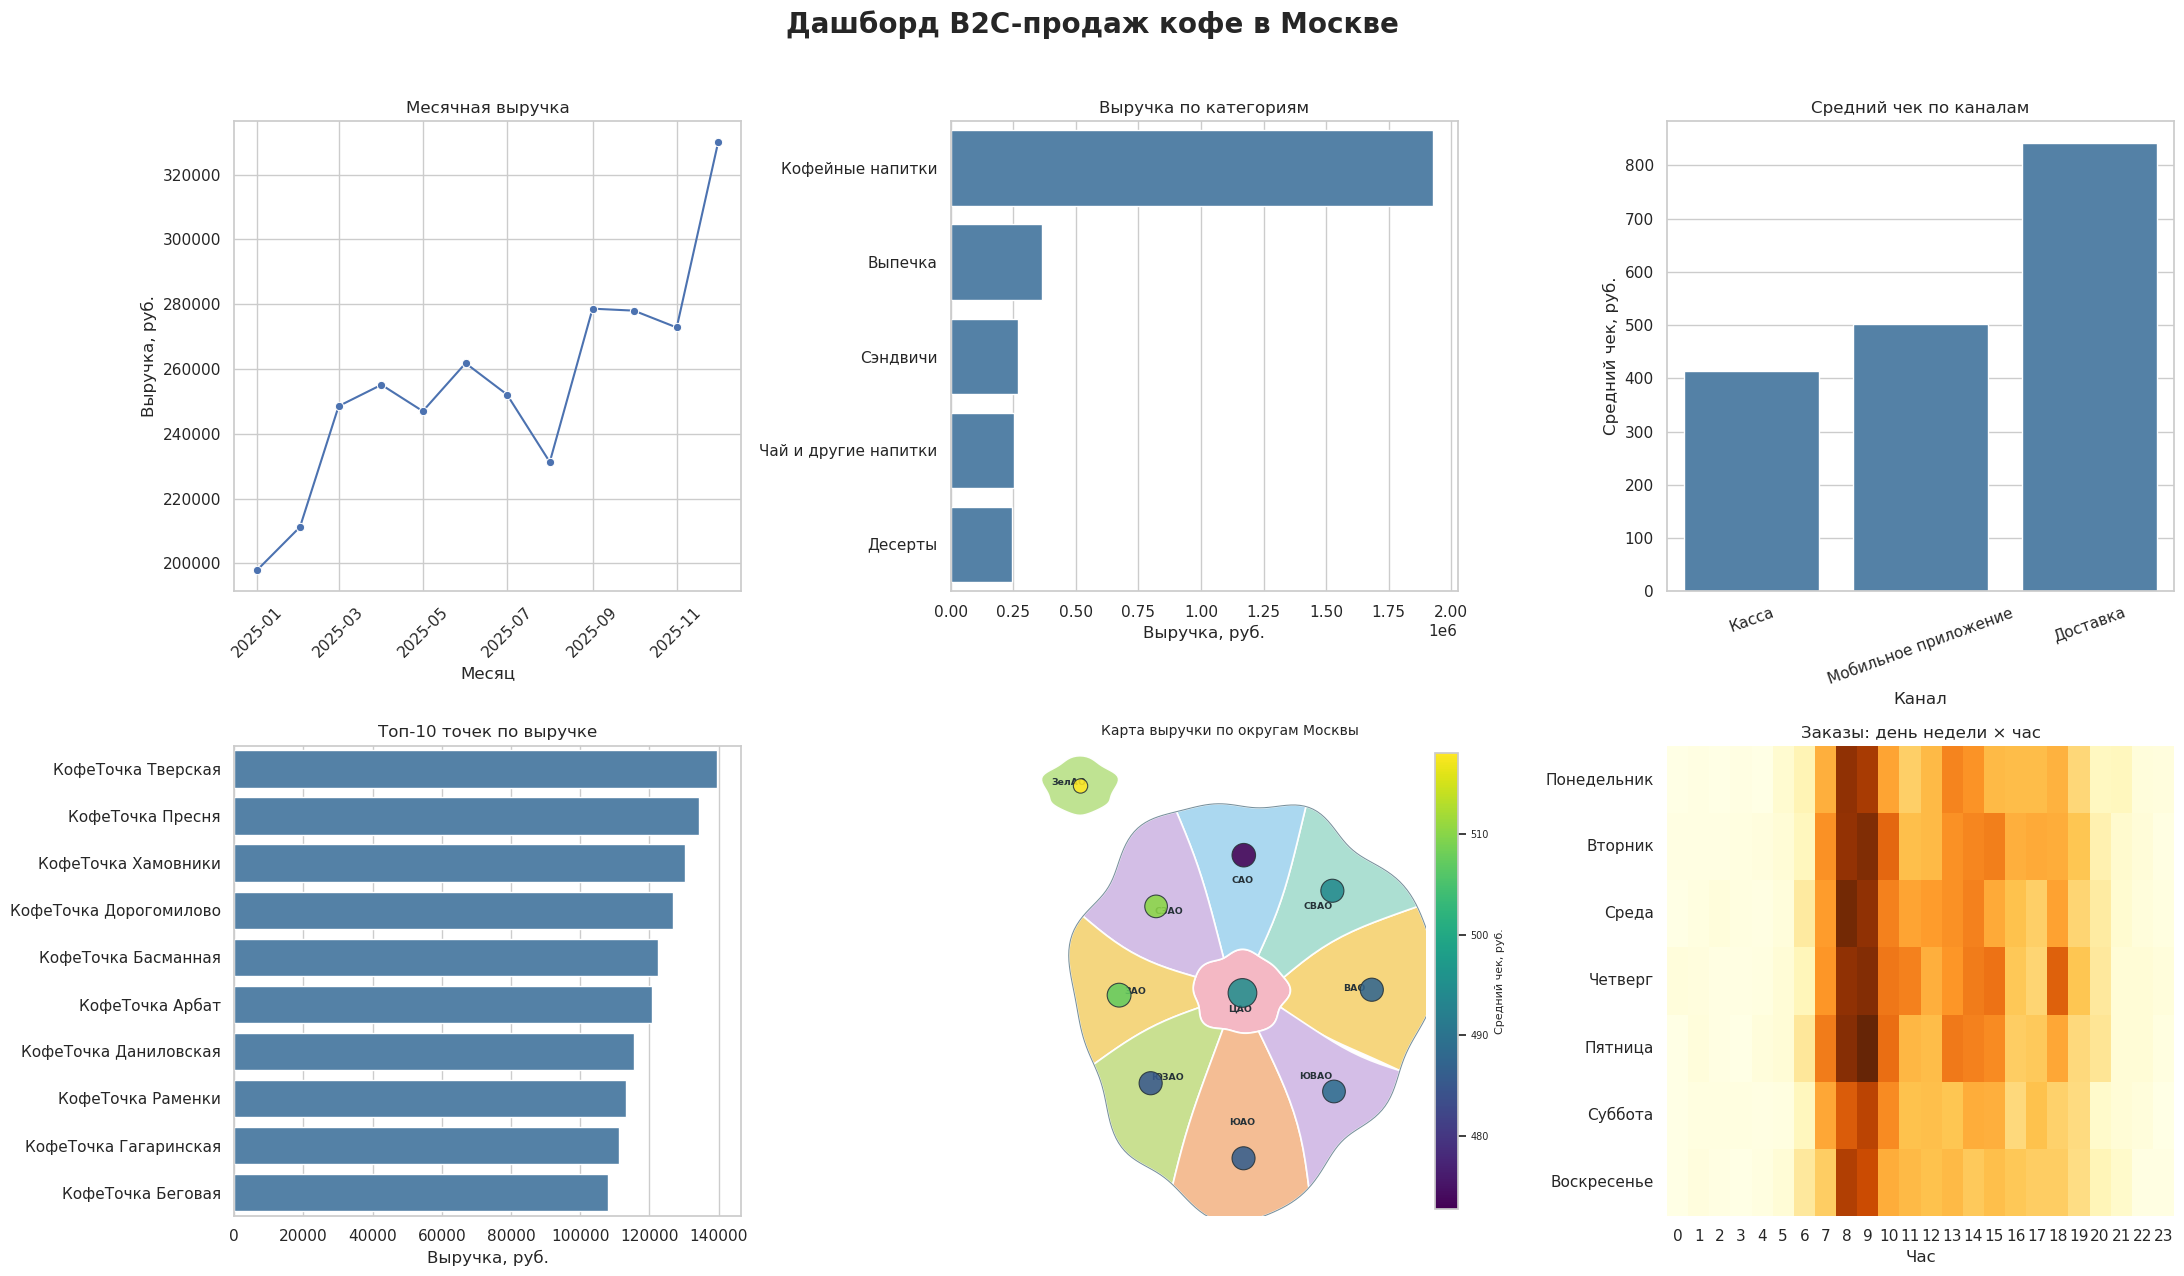

Дашборд сохранён: /home/jovyan/work/19_07_2026/coffee_sales_dashboard.png


In [35]:
# Создаём фигуру дашборда размером 2 строки на 3 столбца.
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
# Добавляем общий заголовок дашборда.
fig.suptitle('Дашборд B2C-продаж кофе в Москве', fontsize=20, fontweight='bold')

# Строим месячную динамику выручки в первой области.
sns.lineplot(data=monthly_summary, x='month', y='revenue_rub', marker='o', ax=axes[0, 0])
# Настраиваем заголовок первой области.
axes[0, 0].set_title('Месячная выручка')
# Настраиваем подпись оси X первой области.
axes[0, 0].set_xlabel('Месяц')
# Настраиваем подпись оси Y первой области.
axes[0, 0].set_ylabel('Выручка, руб.')
# Поворачиваем подписи месяцев первой области.
axes[0, 0].tick_params(axis='x', rotation=45)

# Строим выручку по категориям во второй области.
sns.barplot(data=category_summary, y='product_category', x='revenue_rub', color='steelblue', ax=axes[0, 1])
# Настраиваем заголовок второй области.
axes[0, 1].set_title('Выручка по категориям')
# Настраиваем подпись оси X второй области.
axes[0, 1].set_xlabel('Выручка, руб.')
# Настраиваем подпись оси Y второй области.
axes[0, 1].set_ylabel('')

# Строим средний чек по каналам в третьей области.
sns.barplot(data=channel_summary, x='sales_channel', y='average_order_value_rub', color='steelblue', ax=axes[0, 2])
# Настраиваем заголовок третьей области.
axes[0, 2].set_title('Средний чек по каналам')
# Настраиваем подпись оси X третьей области.
axes[0, 2].set_xlabel('Канал')
# Настраиваем подпись оси Y третьей области.
axes[0, 2].set_ylabel('Средний чек, руб.')
# Поворачиваем подписи каналов третьей области.
axes[0, 2].tick_params(axis='x', rotation=20)

# Выбираем десять точек с максимальной выручкой.
top_stores_dashboard = store_summary.head(10)
# Строим рейтинг точек в четвёртой области.
sns.barplot(data=top_stores_dashboard, y='store_name', x='revenue_rub', color='steelblue', ax=axes[1, 0])
# Настраиваем заголовок четвёртой области.
axes[1, 0].set_title('Топ-10 точек по выручке')
# Настраиваем подпись оси X четвёртой области.
axes[1, 0].set_xlabel('Выручка, руб.')
# Настраиваем подпись оси Y четвёртой области.
axes[1, 0].set_ylabel('')

# Строим программно отрисованную карту Москвы в пятой области дашборда.
dashboard_map_data = draw_moscow_sales_map(
    ax=axes[1, 1],
    district_data=map_district_summary,
    title='Карта выручки по округам Москвы',
    compact=True,
    show_colorbar=True,
    show_size_legend=False
)

# Строим тепловую карту интенсивности заказов в шестой области.
sns.heatmap(weekday_hour_matrix, cmap='YlOrBr', cbar=False, ax=axes[1, 2])
# Настраиваем заголовок шестой области.
axes[1, 2].set_title('Заказы: день недели × час')
# Настраиваем подпись оси X шестой области.
axes[1, 2].set_xlabel('Час')
# Настраиваем подпись оси Y шестой области.
axes[1, 2].set_ylabel('')

# Уменьшаем вертикальные и горизонтальные пересечения элементов.
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Сохраняем дашборд в PNG с высоким разрешением.
fig.savefig(DASHBOARD_PATH, dpi=180, bbox_inches='tight')
# Показываем дашборд в notebook.
plt.show()
# Печатаем путь к сохранённому изображению.
print(f'Дашборд сохранён: {DASHBOARD_PATH.resolve()}')


## 22. Аналитические выводы и рекомендации

Ниже выводы формируются программно на основе рассчитанных таблиц. Формат специально разделяет:

- **факт** — числовой результат;
- **интерпретацию** — возможный смысл наблюдения;
- **ограничение** — что нельзя заключить по текущим данным;
- **рекомендацию** — следующий проверяемый шаг.

In [36]:
# Выбираем категорию с максимальной выручкой.
top_category_row = category_summary.iloc[0]
# Выбираем канал с максимальным средним чеком.
top_aov_channel_row = channel_summary.sort_values('average_order_value_rub', ascending=False).iloc[0]
# Выбираем торговую точку с максимальной выручкой.
top_store_row = store_summary.iloc[0]
# Выбираем административный округ с максимальной выручкой.
top_district_row = district_summary.iloc[0]
# Выбираем месяц с максимальной выручкой.
best_month_row = monthly_summary.sort_values('revenue_rub', ascending=False).iloc[0]
# Выбираем час с максимальным числом заказов.
peak_hour = int(orders_df.groupby('hour')['order_id'].nunique().idxmax())
# Рассчитываем долю выручки класса A.
class_a_share = float(abc_summary.loc[abc_summary['abc_class'] == 'A', 'revenue_share_pct'].iloc[0])
# Рассчитываем число продуктов класса A.
class_a_products = int(abc_summary.loc[abc_summary['abc_class'] == 'A', 'products'].iloc[0])
# Формируем текст статистической интерпретации.
statistical_text = 'Различие статистически значимо при alpha = 0.05' if p_value < 0.05 else 'Статистически значимое различие при alpha = 0.05 не выявлено'
# Создаём итоговый текст в формате Markdown.
final_report = f"""\n### Ключевые факты\n\n1. Очищенный набор содержит **{len(df):,} строк чека** и **{total_orders:,} заказов**. Совокупная выручка составляет **{total_revenue:,.0f} руб.**, валовая прибыль — **{total_gross_profit:,.0f} руб.**, средний чек — **{average_order_value:,.0f} руб.**, валовая маржа — **{overall_margin_pct:.1f}%**.\n2. Категория-лидер — **{top_category_row['product_category']}** с выручкой **{top_category_row['revenue_rub']:,.0f} руб.**\n3. Максимальный средний чек наблюдается в канале **{top_aov_channel_row['sales_channel']}**: **{top_aov_channel_row['average_order_value_rub']:,.0f} руб.**\n4. Точка-лидер — **{top_store_row['store_name']}** ({top_store_row['admin_district']}, {top_store_row['district']}) с выручкой **{top_store_row['revenue_rub']:,.0f} руб.**\n5. Округ-лидер — **{top_district_row['admin_district']}** с выручкой **{top_district_row['revenue_rub']:,.0f} руб.**\n6. Наибольшая месячная выручка зафиксирована в **{best_month_row['month']:%Y-%m}**, а пиковый час по числу заказов — **{peak_hour}:00**.\n7. Класс A включает **{class_a_products} продуктов** и формирует около **{class_a_share:.1f}%** выручки.\n8. Для кассы и приложения: {statistical_text}; разница медиан «приложение − касса» равна **{median_difference:,.0f} руб.**, 95%-й bootstrap-интервал — **[{ci_lower:,.0f}; {ci_upper:,.0f}] руб.**, рангово-бисериальный эффект — **{rank_biserial:.3f}**.\n\n### Интерпретации\n\n- Высокий вклад категории-лидера означает, что изменение спроса или доступности этой категории способно заметно повлиять на общий результат. Однако выручку необходимо рассматривать вместе с маржинальностью и операционными ограничениями.\n- Более высокий средний чек цифрового или доставочного канала может быть связан с размером корзины, промо-механикой и контекстом заказа. Наблюдательные данные не позволяют утверждать, что канал сам по себе причинно увеличивает чек.\n- Концентрация выручки в классе A создаёт одновременно приоритет для контроля наличия и риск зависимости от небольшого числа продуктов.\n\n### Рекомендации как проверяемые следующие шаги\n\n1. Для продуктов класса A настроить регулярный контроль доступности, списаний, маржи и отклонений спроса; критерий готовности — еженедельный отчёт с порогами и владельцем реакции.\n2. Для канала с максимальным средним чеком провести декомпозицию: число позиций, скидка, продуктовый состав и время заказа; затем сформировать A/B-тест конкретной механики, а не делать причинный вывод по текущей ассоциации.\n3. Для лидирующих и отстающих точек сравнить трафик, часы работы, ассортимент и локальные ограничения. Текущий датасет содержит только продажи и не объясняет поток посетителей.\n4. Проверить ассортимент класса C на роль в кросс-продажах и удержании сегментов до решения об оптимизации; удаление только по низкой выручке может быть ошибочным.\n5. Использовать пиковые часы для проверки штатного расписания и скорости обслуживания; для решения потребуются данные о времени ожидания и загрузке персонала.\n"""
# Показываем итоговый аналитический текст.
display(Markdown(final_report))


### Ключевые факты

1. Очищенный набор содержит **9,958 строк чека** и **6,221 заказов**. Совокупная выручка составляет **3,064,314 руб.**, валовая прибыль — **1,855,386 руб.**, средний чек — **493 руб.**, валовая маржа — **60.5%**.
2. Категория-лидер — **Кофейные напитки** с выручкой **1,928,187 руб.**
3. Максимальный средний чек наблюдается в канале **Доставка**: **842 руб.**
4. Точка-лидер — **КофеТочка Тверская** (ЦАО, Тверской) с выручкой **139,524 руб.**
5. Округ-лидер — **ЦАО** с выручкой **647,213 руб.**
6. Наибольшая месячная выручка зафиксирована в **2025-12**, а пиковый час по числу заказов — **9:00**.
7. Класс A включает **12 продуктов** и формирует около **80.0%** выручки.
8. Для кассы и приложения: Различие статистически значимо при alpha = 0.05; разница медиан «приложение − касса» равна **136 руб.**, 95%-й bootstrap-интервал — **[115; 157] руб.**, рангово-бисериальный эффект — **-0.212**.

### Интерпретации

- Высокий вклад категории-лидера означает, что изменение спроса или доступности этой категории способно заметно повлиять на общий результат. Однако выручку необходимо рассматривать вместе с маржинальностью и операционными ограничениями.
- Более высокий средний чек цифрового или доставочного канала может быть связан с размером корзины, промо-механикой и контекстом заказа. Наблюдательные данные не позволяют утверждать, что канал сам по себе причинно увеличивает чек.
- Концентрация выручки в классе A создаёт одновременно приоритет для контроля наличия и риск зависимости от небольшого числа продуктов.

### Рекомендации как проверяемые следующие шаги

1. Для продуктов класса A настроить регулярный контроль доступности, списаний, маржи и отклонений спроса; критерий готовности — еженедельный отчёт с порогами и владельцем реакции.
2. Для канала с максимальным средним чеком провести декомпозицию: число позиций, скидка, продуктовый состав и время заказа; затем сформировать A/B-тест конкретной механики, а не делать причинный вывод по текущей ассоциации.
3. Для лидирующих и отстающих точек сравнить трафик, часы работы, ассортимент и локальные ограничения. Текущий датасет содержит только продажи и не объясняет поток посетителей.
4. Проверить ассортимент класса C на роль в кросс-продажах и удержании сегментов до решения об оптимизации; удаление только по низкой выручке может быть ошибочным.
5. Использовать пиковые часы для проверки штатного расписания и скорости обслуживания; для решения потребуются данные о времени ожидания и загрузке персонала.


## 23. Ограничения анализа

1. Датасет синтетический и предназначен для обучения; его числовые закономерности не описывают реальный рынок кофеен Москвы.
2. Анализ основан только на фактах продаж. Нет данных о трафике, отказах, наличии товара, времени ожидания, аренде, фонде оплаты труда, конкурентах и погоде.
3. Валовая прибыль использует учебную себестоимость и не равна операционной прибыли.
4. Карта программно построена как учебная векторная схема округов. Она показывает относительное расположение территорий, но не воспроизводит официальные административные границы с геодезической точностью и не заменяет ГИС.
5. Сравнение каналов является наблюдательным. Различия могут быть связаны с составом клиентов, временем, ассортиментом и промо.
6. Отсутствующая оценка клиента не является случайным пропуском: отзывы оставляет только часть покупателей.
7. ABC-классы зависят от выбранного периода и границ 80%/95%.
8. Bootstrap-интервал отражает неопределённость внутри данного синтетического набора, но не внешнюю валидность для реального бизнеса.
9. В тесте Манна—Уитни заказы рассматриваются как отдельные наблюдения, хотя часть клиентов совершает повторные покупки; это может занижать неопределённость и требует кластерного подхода в реальном исследовании.

**Уровень уверенности:** высокий для воспроизводимости вычислений внутри созданного датасета; низкий для переноса бизнес-выводов на реальные кофейни.


## 24. Сохранение результатов

Очищенный датасет сохраняется в CSV. Метод `to_csv()` записывает таблицу на диск. Параметр `index=False` предотвращает появление технического столбца индекса, а `encoding='utf-8-sig'` обеспечивает корректное открытие кириллицы в Excel.

In [37]:
# Удаляем временные диагностические флаги, которые больше не нужны в итоговом наборе.
df_to_save = df.drop(columns=['dq_invalid_unit_price', 'dq_invalid_unit_cost', 'dq_invalid_rating'])
# Сохраняем очищенный датасет в CSV без технического индекса.
df_to_save.to_csv(CLEAN_DATA_PATH, index=False, encoding='utf-8-sig')
# Проверяем существование сохранённого CSV.
assert CLEAN_DATA_PATH.exists(), 'Очищенный CSV не был сохранён.'
# Проверяем существование сохранённого дашборда.
assert DASHBOARD_PATH.exists(), 'Дашборд не был сохранён.'
# Печатаем путь к очищенному CSV.
print(f'Очищенный датасет сохранён: {CLEAN_DATA_PATH.resolve()}')
# Печатаем путь к дашборду.
print(f'Изображение дашборда сохранено: {DASHBOARD_PATH.resolve()}')

Очищенный датасет сохранён: /home/jovyan/work/19_07_2026/coffee_sales_moscow_clean.csv
Изображение дашборда сохранено: /home/jovyan/work/19_07_2026/coffee_sales_dashboard.png


## 25. Финальный QA notebook

Notebook считается готовым, если выполнены следующие условия:

- исходный CSV содержит ровно 10 000 строк;
- единица наблюдения явно определена;
- дубликаты, даты, категории, пропуски и числовые бизнес-правила проверены;
- денежные показатели пересчитаны и подтверждены формулами;
- контрольные суммы строк, заказов, категорий и точек совпадают;
- статистический тест содержит H0, H1, alpha, p-value, размер эффекта и интервал неопределённости;
- корреляция не интерпретируется как причинность;
- карта Москвы строится только из Python-координат и объектов `Polygon`/`Circle`;
- в географическом блоке отсутствуют готовые изображения, Base64, `imshow()` и `plt.imread()`;
- каждый аналитический пузырь программно ограничен внутренней областью своего округа;
- географические выводы ограничены учебным характером карты-схемы;
- выводы, ограничения и рекомендации разделены;
- notebook выполняется сверху вниз без скрытого состояния;
- очищенный CSV и итоговый дашборд сохранены.


In [38]:
# Проверяем исходное число строк.
assert len(raw_df) == 10000, 'Исходный CSV должен содержать ровно 10 000 строк.'
# Проверяем уникальность line_id после очистки.
assert df['line_id'].is_unique, 'После очистки line_id должен быть уникальным.'
# Проверяем уникальность order_id в таблице заказов.
assert orders_df['order_id'].is_unique, 'В таблице заказов order_id должен быть уникальным.'
# Проверяем отсутствие пропусков в критических полях.
assert df[critical_columns].isna().sum().sum() == 0, 'В критических полях остались пропуски.'
# Проверяем совпадение общей выручки и категориальной агрегации.
assert np.isclose(total_revenue, category_summary['revenue_rub'].sum()), 'Контроль выручки по категориям не пройден.'
# Проверяем совпадение общей выручки и географической агрегации.
assert np.isclose(total_revenue, store_summary['revenue_rub'].sum()), 'Контроль выручки по точкам не пройден.'
# Проверяем, что статистический результат является конечным числом.
assert np.isfinite(p_value), 'p-value должен быть конечным числом.'
# Проверяем, что размер эффекта находится в допустимом диапазоне.
assert -1 <= rank_biserial <= 1, 'Размер эффекта должен находиться в диапазоне от -1 до 1.'
# Проверяем, что радиус каждого пузыря меньше безопасной доли расстояния до границы округа.
assert (map_plot_data['bubble_radius'] <= map_plot_data['boundary_clearance'] * 0.62 + 1e-9).all(), 'Пузырь может выходить за границу округа.'
# Проверяем, что центры всех пузырей находятся внутри соответствующих полигонов.
for _, bubble_row in map_plot_data.iterrows():
    # Создаём путь полигона соответствующего округа.
    district_path = MplPath(np.asarray(moscow_district_polygons[bubble_row['admin_district']]), closed=True)
    # Проверяем положение центра пузыря внутри полигона.
    assert district_path.contains_point((bubble_row['map_x'], bubble_row['map_y']), radius=-1e-9), f"Центр пузыря {bubble_row['admin_district']} находится вне полигона."
# Проверяем сохранение очищенного датасета.
assert CLEAN_DATA_PATH.exists(), 'Не найден очищенный CSV.'
# Проверяем сохранение дашборда.
assert DASHBOARD_PATH.exists(), 'Не найден файл дашборда.'
# Печатаем итоговый статус QA.
print('QA PASSED: все программные проверки, включая размещение пузырей внутри округов, завершены успешно.')


QA PASSED: все программные проверки, включая размещение пузырей внутри округов, завершены успешно.
